## Descriptive Statistics

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu

In [2]:
# ── Shared constants ──────────────────────────────────────────────────────
COLORS = {"no_tox": "#c7d4c1", "tox": "#c2b594", "single": "#aec0a3"}

CONDITION_NAMES = {
    "hx_smoking":    "Smoking",
    "family_hx_hd":  "Family Heart Disease",
    "hx_htn":        "Hypertension",
    "hx_hld":        "Hyperlipidemia",
    "hx_high_tg":    "High Triglycerides",
    "hx_cad":        "CAD",
    "hx_mi_stent":   "MI / Stent",
    "hx_chf":        "CHF",
    "hx_arrhythmia": "Arrhythmia",
    "hx_carotid":    "Carotid Disease",
    "hx_pad":        "PAD",
    "hx_cva":        "Stroke",
    "hx_dm2":        "Diabetes",
}

RISK_FACTORS = list(CONDITION_NAMES.keys())

CONDITION_FILTER = {
    "hx_smoking":    lambda x: x >= 1,
    **{k: (lambda x: x == 1) for k in RISK_FACTORS if k != "hx_smoking"},
}

INTERVENTION_NAMES = {
    "cards_prior":         "Cardiology (Pre)",
    "cards_post":          "Cardiology (Post)",
    "cards_referral":      "Cardiology Referral",
    "diet_counseling":     "Diet Counseling",
    "exercise_counseling": "Exercise Counseling",
    "echo_ordered":        "Echocardiogram",
    "ecg_done":            "ECG",
}

# ── Reusable plot helpers ──────────────────────────────────────────────────
def toxicity_count_plot(counts, title, xlabel="Number of Patients", ylabel=None,
                        figsize=(6, 4), fontsize=11):
    """Stacked horizontal bar chart: count of no-tox vs tox."""
    fig, ax = plt.subplots(figsize=figsize)
    bars_no  = ax.barh(counts.index, counts[0], color=COLORS["no_tox"], label="No Toxicity")
    bars_yes = ax.barh(counts.index, counts[1], left=counts[0],
                       color=COLORS["tox"], label="Toxicity")
    for bars, vals in [(bars_no, counts[0]), (bars_yes, counts[1])]:
        ax.bar_label(bars, labels=[str(v) if v > 0 else "" for v in vals],
                     label_type="center", fontsize=fontsize)
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def toxicity_prop_plot(counts, title, xlabel="Proportion of Patients", ylabel=None,
                       figsize=(6, 4)):
    """Stacked horizontal bar chart: proportion of no-tox vs tox."""
    props = counts.div(counts.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=figsize)
    bars_no  = ax.barh(props.index, props[0], color=COLORS["no_tox"], label="No Toxicity")
    bars_yes = ax.barh(props.index, props[1], left=props[0],
                       color=COLORS["tox"], label="Toxicity")
    for bars, vals in [(bars_no, props[0]), (bars_yes, props[1])]:
        ax.bar_label(bars, labels=[f"{p:.2f}" if p > 0 else "" for p in vals],
                     label_type="center", fontsize=9)
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def nht_counts_by_group(subset_df, group_col="specific_nht_used"):
    """Return toxicity counts sorted ascending by total."""
    counts = (
        subset_df.groupby([group_col, "at_risk"])["unique_patient_id"]
        .nunique()
        .unstack(fill_value=0)
    )
    return counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]


def nht_stats(subset_df, label=""):
    """Print risk rates and chi2/Fisher p-values for Abiraterone vs Darolutamide."""
    rates = subset_df.groupby("specific_nht_used")["at_risk"].mean()
    print(rates)
    if "Abiraterone" in rates.index and "Darolutamide" in rates.index:
        print(f"Risk diff (Abiraterone - Darolutamide): {rates['Abiraterone'] - rates['Darolutamide']:.4f}")
    sub = subset_df[subset_df["specific_nht_used"].isin(["Darolutamide", "Abiraterone"])]
    table      = pd.crosstab(sub["specific_nht_used"], sub["at_risk"])
    full_table = pd.crosstab(subset_df["specific_nht_used"], subset_df["at_risk"])
    chi2, p, *_ = chi2_contingency(table)
    print(f"Chi-square p-value: {p:.4f}")
    _, p = fisher_exact(table)
    print(f"Fisher's Exact p-value: {p:.4f}")
    chi2, p, *_ = chi2_contingency(full_table)
    print(f"Chi-square p-value (full): {p:.4f}")
    _, p = fisher_exact(full_table)
    print(f"Fisher's Exact p-value (full): {p:.4f}")


def hx_nht_analysis(df, col, condition_label):
    """Count + proportion bar charts and stats for one health-history subgroup vs NHT."""
    subset = df[CONDITION_FILTER[col](df[col])]
    counts = nht_counts_by_group(subset)
    toxicity_count_plot(counts,
                        title=f"Number of At Risk Patients with {condition_label} by NHT",
                        ylabel="Type of NHT")
    toxicity_prop_plot(counts,
                       title=f"Proportion of Toxicity in Patients with {condition_label} by NHT",
                       ylabel="Type of NHT")
    nht_stats(subset)


def styled_bar_chart(ax):
    """Apply consistent grey-grid styling to a grouped bar chart."""
    ax.set_facecolor("#f0f0f0")
    ax.yaxis.grid(True, color="white", linewidth=0.7)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False)

### Load Data

In [3]:
df = pd.read_csv(os.path.join("..", "data", "processed", "cardio_onc_prostate_04cleaned.csv"))

bins   = np.arange(45, df["age"].max() + 5, 5)
labels = [f"{int(b)}\u2013{int(b+4)}" for b in bins[:-1]]
df["age_bin"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

tox    = df[df["at_risk"] == 1]
no_tox = df[df["at_risk"] == 0]

### Descriptives of At Risk Patients

In [4]:
cont_vars = ["age", "bmi", "ascvd_10yr", "sbp", "dbp"]

print("Age median:", df["age"].median())
print("BMI median:", df["bmi"].median())
print("Age std:   ", df["age"].std())
print("BMI std:   ", df["bmi"].std())

print("\nBy at_risk group:")
print(df.groupby("at_risk")[cont_vars].agg(["mean", "std"]))

print("\nOverall:")
print(df[cont_vars].agg(["mean", "std"]))

cat_vars = [
    "ethnicity", "hx_smoking", "hx_htn", "hx_hld", "hx_dm2",
    "hx_cad", "hx_chf", "hx_arrhythmia", "hx_pad", "hx_cva",
    "has_pcp", "lipid_panel_checked", "a1c_checked",
    "cards_prior", "diet_counseling", "exercise_counseling",
]

for v in cat_vars:
    print(f"\n{v}")
    print(pd.crosstab(df["at_risk"], df[v], normalize="columns") * 100)

Age median: 71.0
BMI median: 27.53
Age std:    8.295910015872641
BMI std:    4.775503987591421

By at_risk group:
               age                  bmi           ascvd_10yr            \
              mean       std       mean       std       mean       std   
at_risk                                                                  
0.0      71.766129  9.337492  27.801290  5.194846   1.774194  0.419809   
1.0      71.405063  8.460343  27.521266  5.080351   1.835443  0.373149   

                sbp                   dbp            
               mean        std       mean       std  
at_risk                                              
0.0      129.733871  13.662666  73.629032  7.867260  
1.0      130.759494  14.506599  73.392405  8.662353  

Overall:
            age        bmi  ascvd_10yr         sbp        dbp
mean  71.518828  27.646025    1.828452  129.962343  73.606695
std    8.295910   4.775504    0.377778   12.877030   7.524478

ethnicity
ethnicity      Asian      Black  Cauca

### Baseline Demographics
Age

C:\Users\tiffa\AppData\Local\Temp\ipykernel_9052\1126946776.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["age_bin", "at_risk"])["unique_patient_id"]


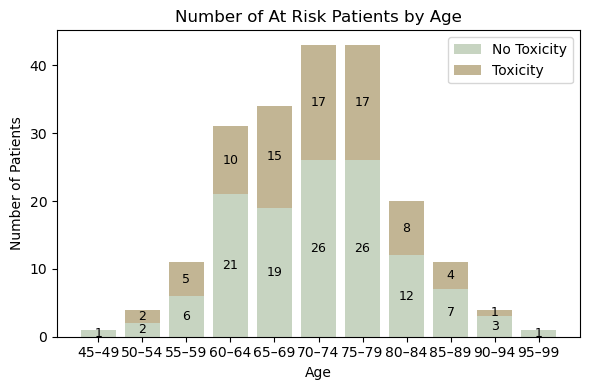

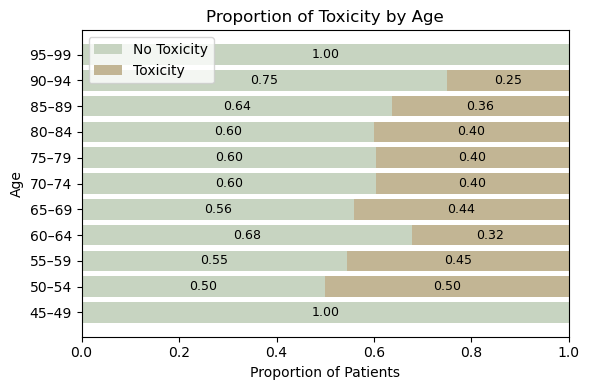

In [5]:
counts = (
    df.groupby(["age_bin", "at_risk"])["unique_patient_id"]
    .nunique()
    .unstack(fill_value=0)
)

# Count chart (vertical)
fig, ax = plt.subplots(figsize=(6, 4))
bars_no  = ax.bar(counts.index.astype(str), counts[0],
                  color=COLORS["no_tox"], label="No Toxicity")
bars_yes = ax.bar(counts.index.astype(str), counts[1], bottom=counts[0],
                  color=COLORS["tox"], label="Toxicity")
for bars, vals in [(bars_no, counts[0]), (bars_yes, counts[1])]:
    ax.bar_label(bars, labels=[str(v) if v > 0 else "" for v in vals],
                 label_type="center", fontsize=9)
ax.set_xlabel("Age")
ax.set_ylabel("Number of Patients")
ax.set_title("Number of At Risk Patients by Age")
ax.legend()
plt.tight_layout()
plt.show()

toxicity_prop_plot(counts, title="Proportion of Toxicity by Age",
                   xlabel="Proportion of Patients", ylabel="Age")

Ethnicity

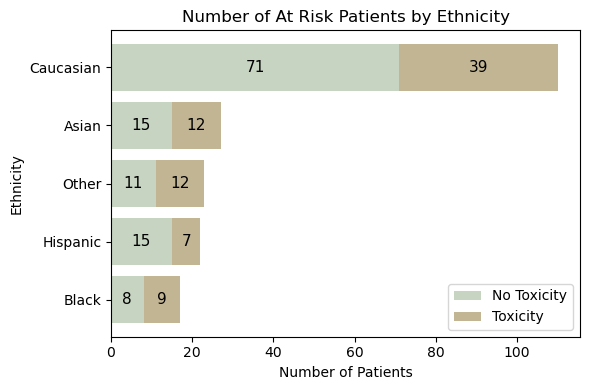

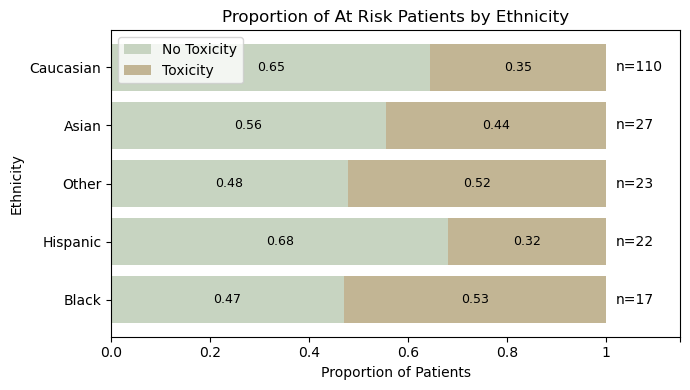

In [6]:
counts = nht_counts_by_group(df, group_col="ethnicity")
counts = counts[counts.sum(axis=1) >= 2]
totals = counts.sum(axis=1)

toxicity_count_plot(counts, title="Number of At Risk Patients by Ethnicity",
                    xlabel="Number of Patients", ylabel="Ethnicity", figsize=(6, 4))

# Proportion with n= annotations
props = counts.div(totals, axis=0)
fig, ax = plt.subplots(figsize=(7, 4))
bars_no  = ax.barh(props.index, props[0], color=COLORS["no_tox"], label="No Toxicity")
bars_yes = ax.barh(props.index, props[1], left=props[0], color=COLORS["tox"], label="Toxicity")
for bars, vals in [(bars_no, props[0]), (bars_yes, props[1])]:
    ax.bar_label(bars, labels=[f"{p:.2f}" if p > 0 else "" for p in vals],
                 label_type="center", fontsize=9)
for i, (idx, total) in enumerate(totals.items()):
    ax.text(1.02, i, f"n={int(total)}", va="center")
ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1, 1.15],
              [0.0, 0.2, 0.4, 0.6, 0.8, 1, ""])
ax.set_xlabel("Proportion of Patients")
ax.set_ylabel("Ethnicity")
ax.set_title("Proportion of At Risk Patients by Ethnicity")
ax.legend()
plt.tight_layout()
plt.show()

BMI

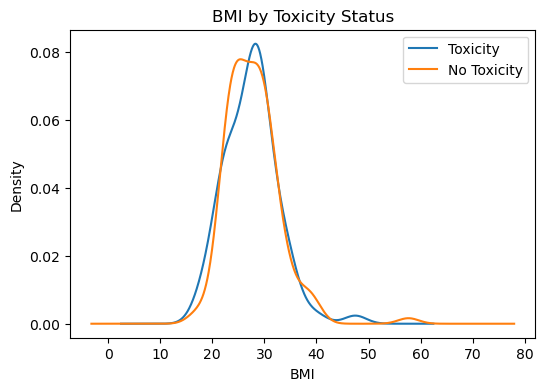

Median BMI (No Toxicity): 27.41
Median BMI (Toxicity):    27.60
Median Difference:        0.20
Mann-Whitney U p-value: 0.8580


In [7]:
tox["bmi"].dropna().plot(kind="density", figsize=(6, 4), label="Toxicity")
no_tox["bmi"].dropna().plot(kind="density", label="No Toxicity")
plt.xlabel("BMI"); plt.ylabel("Density")
plt.title("BMI by Toxicity Status"); plt.legend(); plt.show()

bmi_summary = df.groupby("at_risk")["bmi"].median()
print(f"Median BMI (No Toxicity): {bmi_summary[0]:.2f}")
print(f"Median BMI (Toxicity):    {bmi_summary[1]:.2f}")
print(f"Median Difference:        {bmi_summary[1] - bmi_summary[0]:.2f}")

stat, pval = mannwhitneyu(tox["bmi"].dropna(), no_tox["bmi"].dropna(), alternative="two-sided")
print(f"Mann-Whitney U p-value: {pval:.4f}")

Age vs. BMI

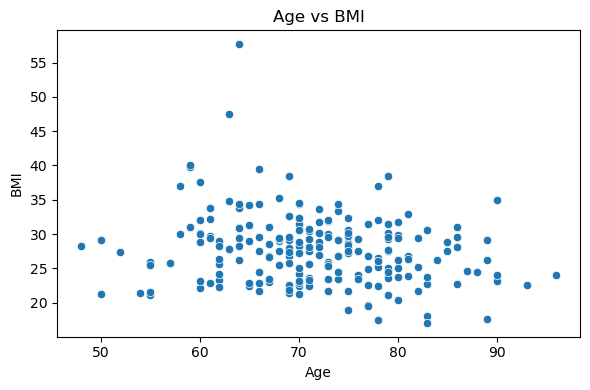

In [8]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="age", y="bmi")
plt.xlabel("Age"); plt.ylabel("BMI"); plt.title("Age vs BMI")
plt.tight_layout(); plt.show()

Counts of Toxicity based on Baseline Risk Factor

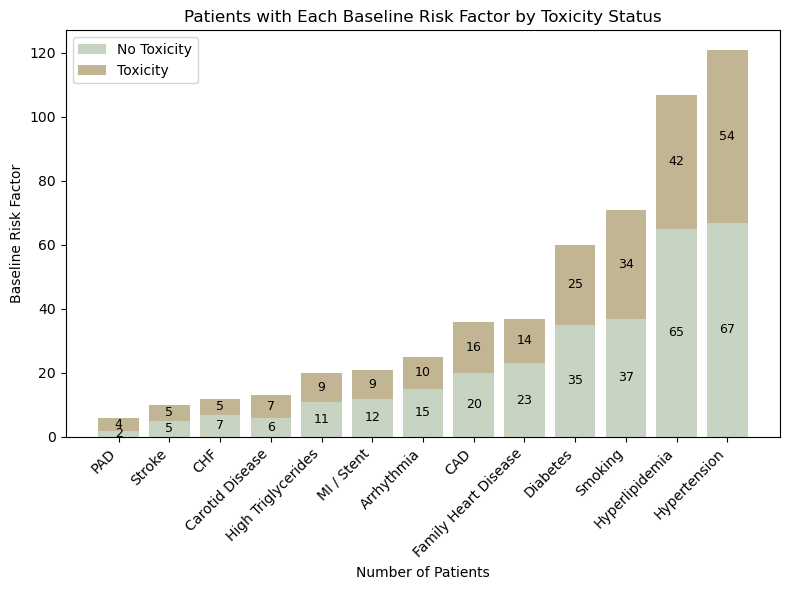

In [9]:
long_df = (
    df.melt(id_vars=["unique_patient_id", "at_risk"],
            value_vars=RISK_FACTORS,
            var_name="condition", value_name="has_condition")
    .query("has_condition == 1")
)
long_df["condition"] = long_df["condition"].map(CONDITION_NAMES)

counts = (
    long_df.groupby(["condition", "at_risk"])["unique_patient_id"]
    .nunique().unstack(fill_value=0)
    .rename(columns={0: "No Toxicity", 1: "Toxicity"})
)
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(8, 6))
bars_no  = ax.bar(counts.index, counts["No Toxicity"],
                  color=COLORS["no_tox"], label="No Toxicity")
bars_yes = ax.bar(counts.index, counts["Toxicity"],
                  bottom=counts["No Toxicity"],
                  color=COLORS["tox"], label="Toxicity")
ax.bar_label(bars_no,  label_type="center", fontsize=9)
ax.bar_label(bars_yes, label_type="center", fontsize=9)
ax.set_xlabel("Number of Patients")
ax.set_ylabel("Baseline Risk Factor")
ax.set_title("Patients with Each Baseline Risk Factor by Toxicity Status")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

Proportion of Patients in Toxicity Group that had Baseline Risk Factor

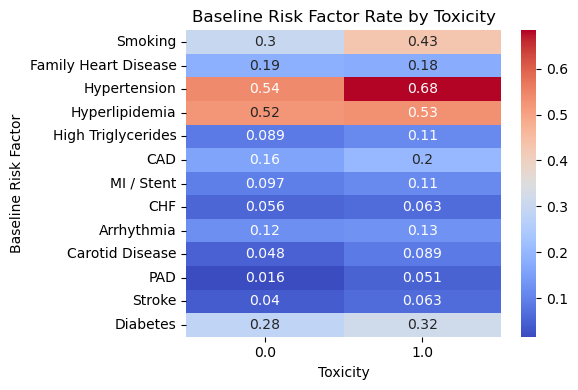

In [10]:
heat = df.groupby("at_risk")[RISK_FACTORS].mean().T
heat.index = heat.index.map(CONDITION_NAMES)

plt.figure(figsize=(6, 4))
sns.heatmap(heat, annot=True, cmap="coolwarm")
plt.title("Baseline Risk Factor Rate by Toxicity")
plt.xlabel("Toxicity"); plt.ylabel("Baseline Risk Factor")
plt.tight_layout()

Proportion of Patients with Baseline Disease that Developed Toxicity

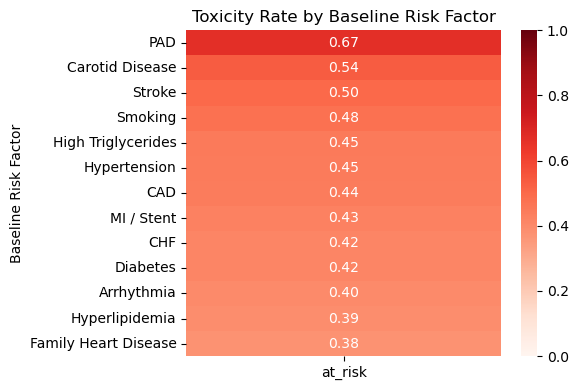

In [11]:
heatmap_data = [
    {"condition": col, "at_risk": df[CONDITION_FILTER[col](df[col])]["at_risk"].mean()}
    for col in RISK_FACTORS
]
heatmap_df = (
    pd.DataFrame(heatmap_data)
    .set_index("condition")
    .sort_values("at_risk", ascending=False)
)
heatmap_df.index = heatmap_df.index.map(CONDITION_NAMES)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(heatmap_df, annot=True, cmap="Reds", vmin=0, vmax=1,
                 fmt=".2f", annot_kws={"color": "white", "fontsize": 10})
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.title("Toxicity Rate by Baseline Risk Factor")
plt.xlabel(""); plt.ylabel("Baseline Risk Factor")
plt.tight_layout(); plt.show()

### ADT and NHT Measures
NHT and ADT Counts

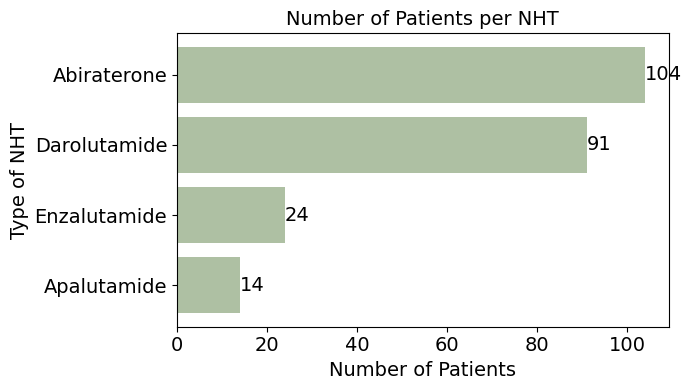

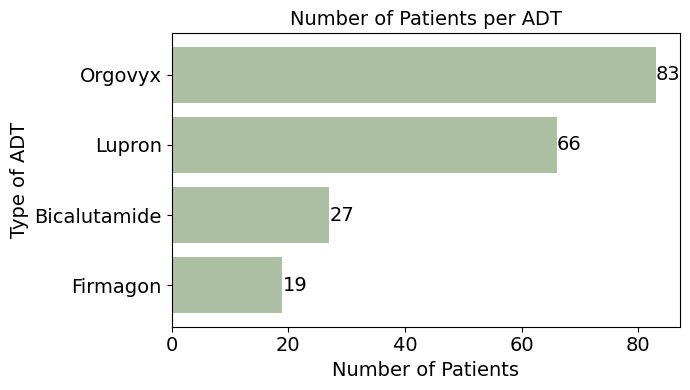

In [12]:
for group_col, title_label in [("specific_nht_used", "NHT"), ("adt_agent", "ADT")]:
    num_patients = df.groupby(group_col)["unique_patient_id"].nunique().sort_values()
    fig, ax = plt.subplots(figsize=(7, 4))
    p = ax.barh(num_patients.index, num_patients.values, color=COLORS["single"])
    ax.bar_label(p, label_type="edge", fontsize=14)
    ax.set_ylabel(f"Type of {title_label}", fontsize=14)
    ax.set_xlabel("Number of Patients", fontsize=14)
    ax.set_title(f"Number of Patients per {title_label}", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)
    plt.tight_layout(); plt.show()

NHT and ADT Combinations

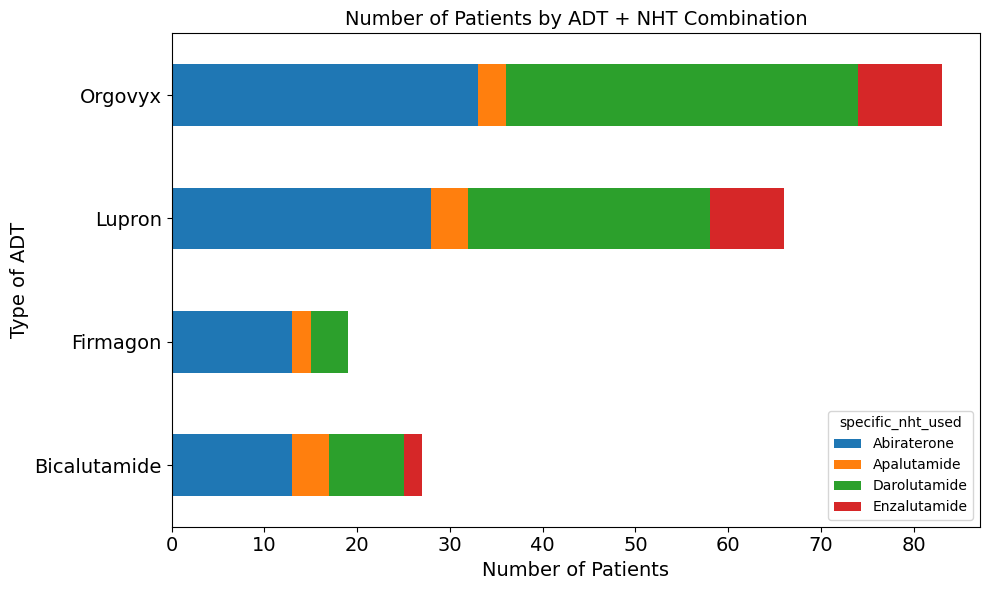

In [13]:
combo_counts = (
    df.groupby(["adt_agent", "specific_nht_used"])["unique_patient_id"]
    .nunique().unstack(fill_value=0)
)
fig, ax = plt.subplots(figsize=(10, 6))
combo_counts.plot(kind="barh", stacked=True, ax=ax)
ax.set_ylabel("Type of ADT", fontsize=14)
ax.set_xlabel("Number of Patients", fontsize=14)
ax.set_title("Number of Patients by ADT + NHT Combination", fontsize=14)
ax.tick_params(axis="both", labelsize=14)
plt.tight_layout(); plt.show()

Toxicity by NHT / ADT

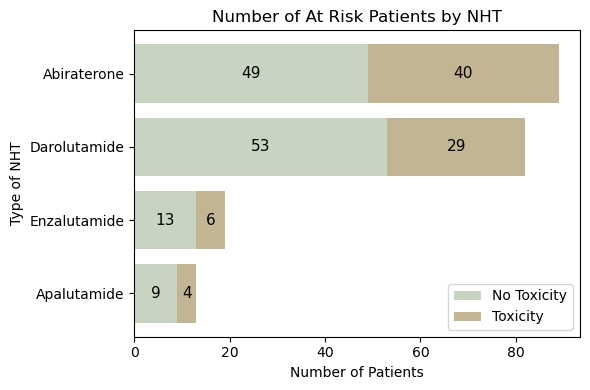

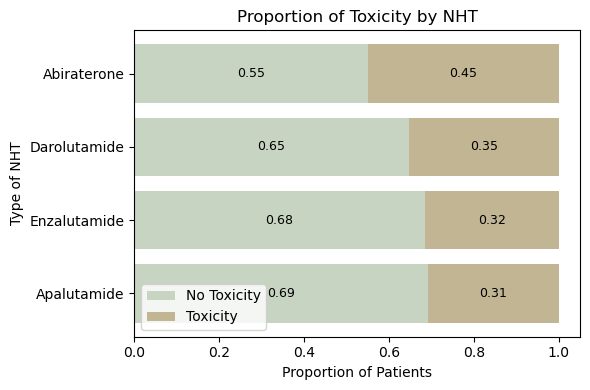

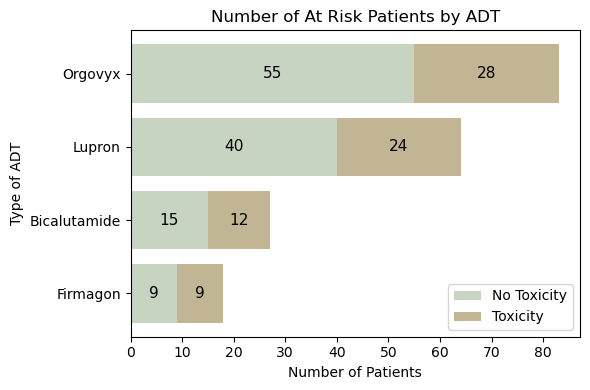

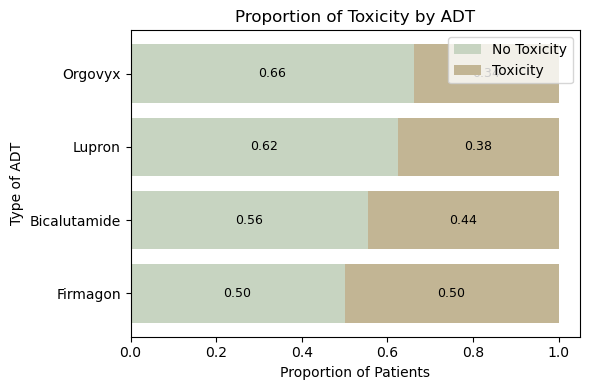

In [14]:
for group_col, ylabel in [("specific_nht_used", "Type of NHT"), ("adt_agent", "Type of ADT")]:
    counts = nht_counts_by_group(df, group_col=group_col)
    toxicity_count_plot(counts,
                        title=f"Number of At Risk Patients by {ylabel.split()[-1]}",
                        ylabel=ylabel)
    toxicity_prop_plot(counts,
                       title=f"Proportion of Toxicity by {ylabel.split()[-1]}",
                       ylabel=ylabel)

Counts of Type of Toxicity by NHT and ADT

In [15]:
all_df = pd.read_csv(os.path.join("..", "data", "processed",
                                    "cardio_onc_prostate_06_broad_clean.csv"))
all_df = all_df[all_df["at_risk"].notna()]

tox_cols = ["bp_meds_post_binary", "lipid_meds_post_binary", "dm_meds_post_binary"]

for group_col in ["specific_nht_used", "adt_agent"]:
    for tox_col in tox_cols:
        counts = (
            all_df.groupby([group_col, tox_col])["unique_patient_id"]
            .nunique().unstack(fill_value=0)
        )
        counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]
        print(f"\n{group_col} × {tox_col}")
        print(counts)


specific_nht_used × bp_meds_post_binary
bp_meds_post_binary  0.0  1.0
specific_nht_used            
Apalutamide           11    2
Enzalutamide          16    3
Darolutamide          69   12
Abiraterone           69   20

specific_nht_used × lipid_meds_post_binary
lipid_meds_post_binary  0.0  1.0
specific_nht_used               
Apalutamide              11    2
Enzalutamide             17    2
Darolutamide             74    8
Abiraterone              73   16

specific_nht_used × dm_meds_post_binary
dm_meds_post_binary  0.0  1.0
specific_nht_used            
Apalutamide           12    1
Enzalutamide          16    3
Darolutamide          65   17
Abiraterone           68   20

adt_agent × bp_meds_post_binary
bp_meds_post_binary  0.0  1.0
adt_agent                    
Firmagon              10    7
Bicalutamide          22    5
Lupron                51   13
Orgovyx               74    9

adt_agent × lipid_meds_post_binary
lipid_meds_post_binary  0.0  1.0
adt_agent                       
F

Darolutamide vs. Abiraterone and Orgovyx vs. Lupron Significance

In [16]:
print("=== NHT: Darolutamide vs. Abiraterone ===")
nht_stats(df)

print("\n=== ADT: Orgovyx vs. Lupron ===")
rates = df.groupby("adt_agent")["at_risk"].mean()
print(rates)
print(f"Risk diff (Lupron - Orgovyx): {rates['Lupron'] - rates['Orgovyx']:.4f}")
subset = df[df["adt_agent"].isin(["Orgovyx", "Lupron"])]
table = pd.crosstab(subset["adt_agent"], subset["at_risk"])
chi2, p, *_ = chi2_contingency(table)
print(f"Chi-square p-value: {p:.4f}")

=== NHT: Darolutamide vs. Abiraterone ===
specific_nht_used
Abiraterone     0.449438
Apalutamide     0.307692
Darolutamide    0.353659
Enzalutamide    0.315789
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.0958
Chi-square p-value: 0.2630
Fisher's Exact p-value: 0.2157
Chi-square p-value (full): 0.4595
Fisher's Exact p-value (full): 0.4878

=== ADT: Orgovyx vs. Lupron ===
adt_agent
Bicalutamide    0.444444
Firmagon        0.500000
Lupron          0.375000
Orgovyx         0.337349
Name: at_risk, dtype: float64
Risk diff (Lupron - Orgovyx): 0.0377
Chi-square p-value: 0.7646


Toxicity Rate by ADT and NHT Combination

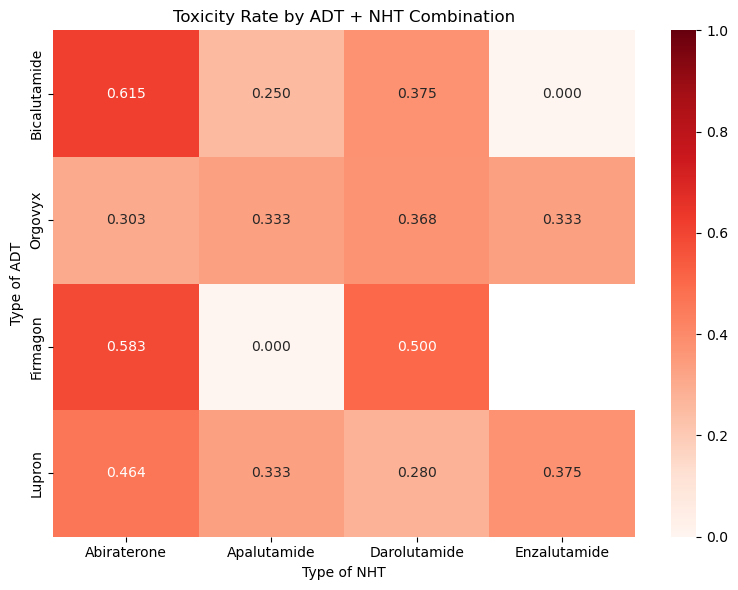

In [17]:
df_atrisk = df[df["at_risk"].notna()]

def patient_counts(source_df):
    return (
        source_df[["unique_patient_id", "adt_agent", "specific_nht_used"]]
        .drop_duplicates()
        .groupby(["adt_agent", "specific_nht_used"])["unique_patient_id"]
        .nunique().unstack(fill_value=0)
    )

total_counts = patient_counts(df_atrisk)
tox_counts   = patient_counts(df_atrisk[df_atrisk["at_risk"] == 1]).reindex(
    index=total_counts.index, columns=total_counts.columns, fill_value=0)

valid_rows = total_counts.sum(axis=1) > 3
valid_cols = total_counts.sum(axis=0) > 3
total_counts = total_counts.loc[valid_rows, valid_cols]
tox_counts   = tox_counts.loc[valid_rows, valid_cols]

tox_rate = tox_counts.div(total_counts.replace(0, np.nan))
tox_rate = tox_rate.loc[tox_rate.mean(axis=1).sort_values().index]

plt.figure(figsize=(8, 6))
ax = sns.heatmap(tox_rate, annot=True, fmt=".3f", cmap="Reds", vmin=0, vmax=1)
ax.set_xlabel("Type of NHT"); ax.set_ylabel("Type of ADT")
ax.set_title("Toxicity Rate by ADT + NHT Combination")
plt.tight_layout(); plt.show()

Top Four Combination Toxicity / All Combinations

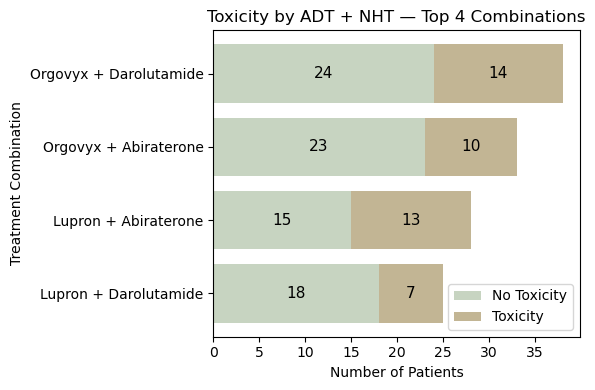

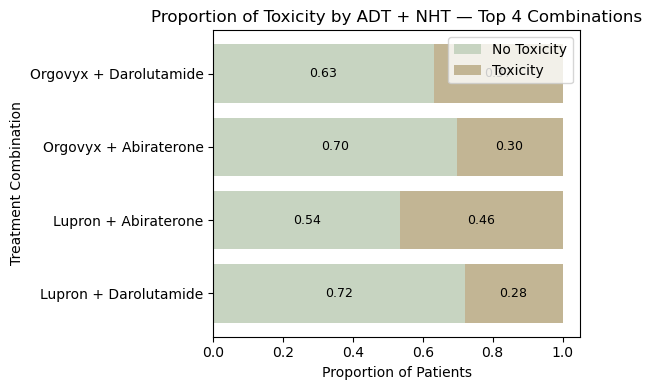

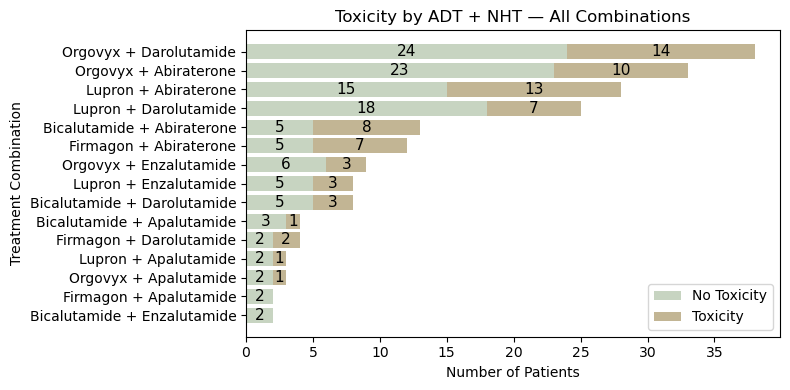

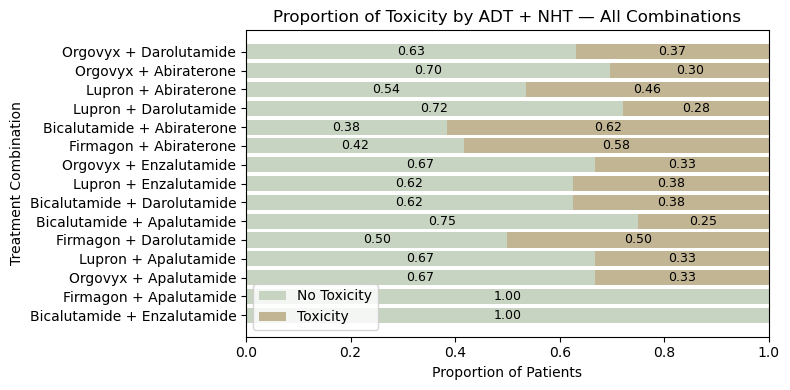

In [18]:
df["combo"] = df["adt_agent"] + " + " + df["specific_nht_used"]

for label, subset_df in [
    ("Top 4 Combinations",
     df[df["adt_agent"].isin(["Orgovyx", "Lupron"]) &
        df["specific_nht_used"].isin(["Darolutamide", "Abiraterone"])].copy()),
    ("All Combinations", df),
]:
    figsize = (6, 4) if "Top" in label else (8, 4)
    counts = nht_counts_by_group(subset_df, group_col="combo")
    toxicity_count_plot(counts, title=f"Toxicity by ADT + NHT — {label}",
                        xlabel="Number of Patients", ylabel="Treatment Combination",
                        figsize=figsize)
    toxicity_prop_plot(counts, title=f"Proportion of Toxicity by ADT + NHT — {label}",
                       ylabel="Treatment Combination", figsize=figsize)

### Time Period Length Between ADT and NHT Start

count      192.000000
mean       509.213542
std       3146.876234
min       -731.000000
25%          0.000000
50%         28.000000
75%        184.750000
max      42759.000000
Name: days_adt_to_nht, dtype: float64


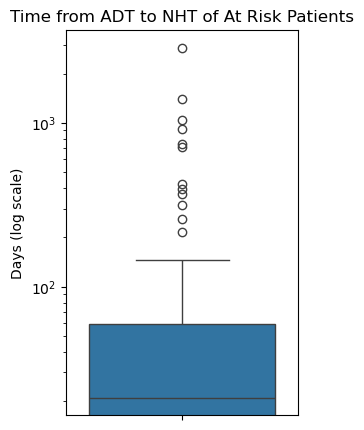

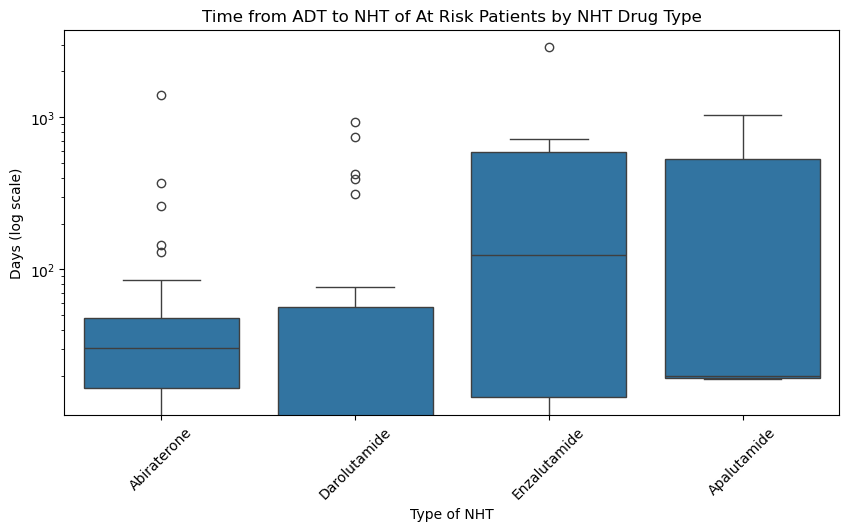

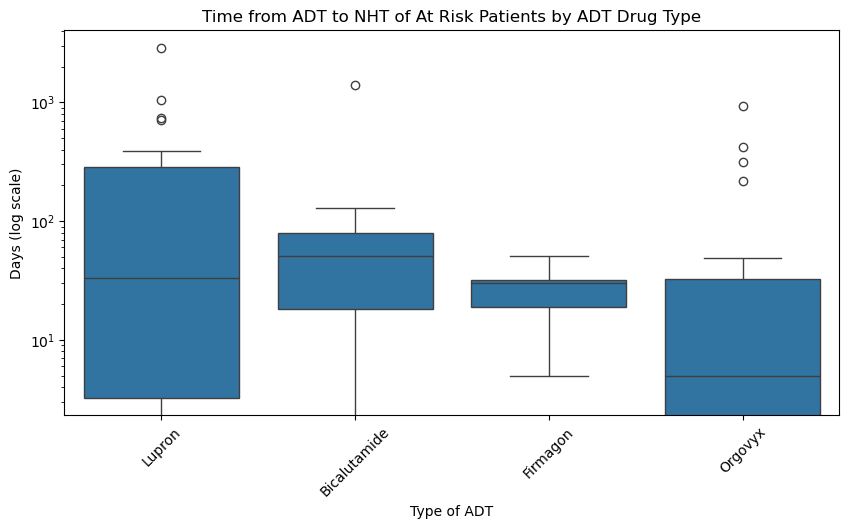

In [19]:
print(df["days_adt_to_nht"].describe())

# Overall
plt.figure(figsize=(3, 5))
sns.boxplot(data=tox, y="days_adt_to_nht")
plt.yscale("log")
plt.title("Time from ADT to NHT of At Risk Patients")
plt.ylabel("Days (log scale)"); plt.show()

# By NHT and ADT
for x_col, xlabel, title_suffix in [
    ("specific_nht_used", "Type of NHT", "NHT Drug Type"),
    ("adt_agent",         "Type of ADT", "ADT Drug Type"),
]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=tox, x=x_col, y="days_adt_to_nht")
    plt.yscale("log"); plt.xticks(rotation=45)
    plt.title(f"Time from ADT to NHT of At Risk Patients by {title_suffix}")
    plt.xlabel(xlabel); plt.ylabel("Days (log scale)")
    plt.show()

### Health History vs. NHT


History of Hypertension


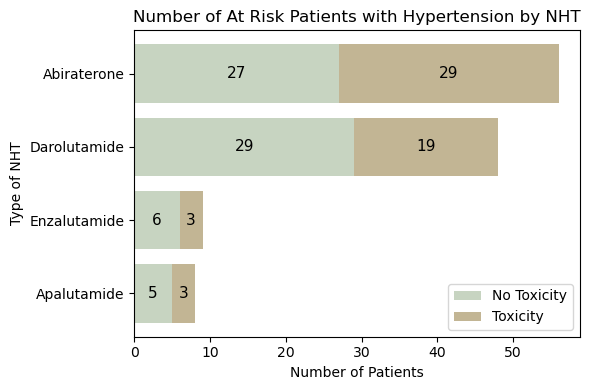

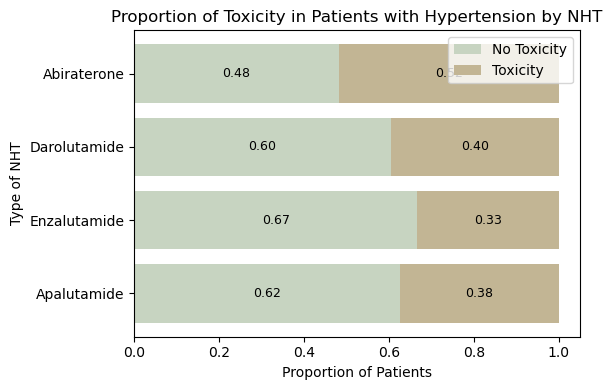

specific_nht_used
Abiraterone     0.517857
Apalutamide     0.375000
Darolutamide    0.395833
Enzalutamide    0.333333
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.1220
Chi-square p-value: 0.2950
Fisher's Exact p-value: 0.2408
Chi-square p-value (full): 0.5155
Fisher's Exact p-value (full): 0.5092
  nan vs Apalutamide: p = 1.000
  nan vs Abiraterone: p = 1.000
  nan vs Darolutamide: p = 1.000
  nan vs Enzalutamide: p = 1.000
  Apalutamide vs Abiraterone: p = 0.708
  Apalutamide vs Darolutamide: p = 1.000
  Apalutamide vs Enzalutamide: p = 1.000
  Abiraterone vs Darolutamide: p = 0.241
  Abiraterone vs Enzalutamide: p = 0.475
  Darolutamide vs Enzalutamide: p = 1.000

History of Hyperlipidemia


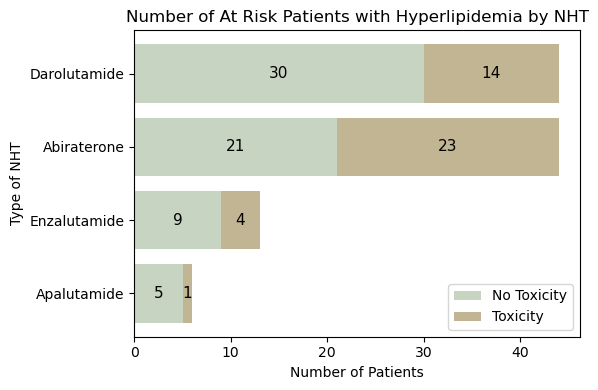

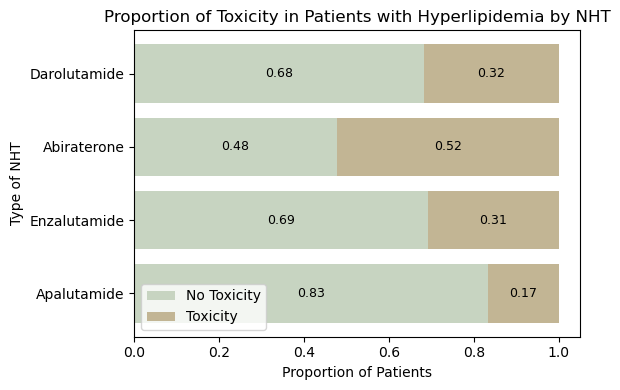

specific_nht_used
Abiraterone     0.522727
Apalutamide     0.166667
Darolutamide    0.318182
Enzalutamide    0.307692
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.2045
Chi-square p-value: 0.0841
Fisher's Exact p-value: 0.0834
Chi-square p-value (full): 0.1205
Fisher's Exact p-value (full): 0.1381
  nan vs Apalutamide: p = 1.000
  nan vs Abiraterone: p = 1.000
  nan vs Darolutamide: p = 1.000
  nan vs Enzalutamide: p = 1.000
  Apalutamide vs Abiraterone: p = 0.192
  Apalutamide vs Darolutamide: p = 0.654
  Apalutamide vs Enzalutamide: p = 1.000
  Abiraterone vs Darolutamide: p = 0.083
  Abiraterone vs Enzalutamide: p = 0.216
  Darolutamide vs Enzalutamide: p = 1.000

History of Diabetes


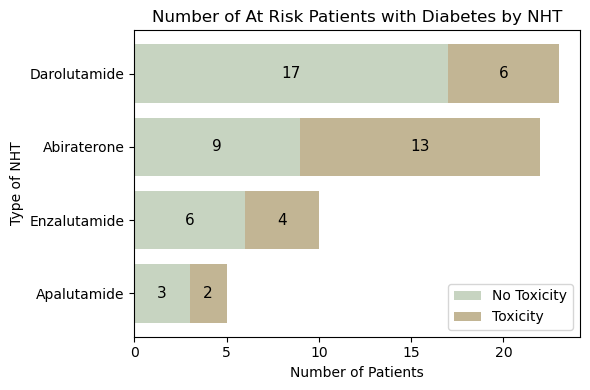

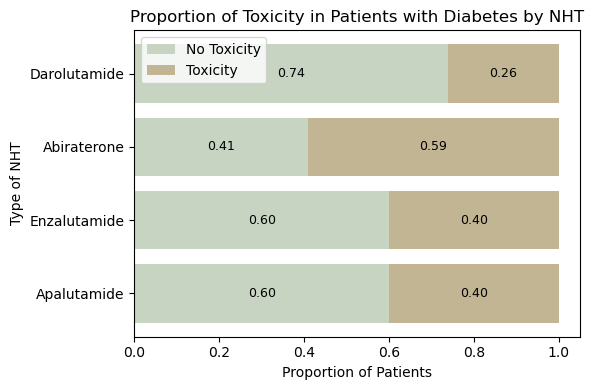

specific_nht_used
Abiraterone     0.590909
Apalutamide     0.400000
Darolutamide    0.260870
Enzalutamide    0.400000
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.3300
Chi-square p-value: 0.0525
Fisher's Exact p-value: 0.0361
Chi-square p-value (full): 0.1673
Fisher's Exact p-value (full): 0.1613
  Abiraterone vs Enzalutamide: p = 0.450
  Abiraterone vs Darolutamide: p = 0.036
  Abiraterone vs Apalutamide: p = 0.628
  Enzalutamide vs Darolutamide: p = 0.444
  Enzalutamide vs Apalutamide: p = 1.000
  Darolutamide vs Apalutamide: p = 0.606

History of MI / Stent


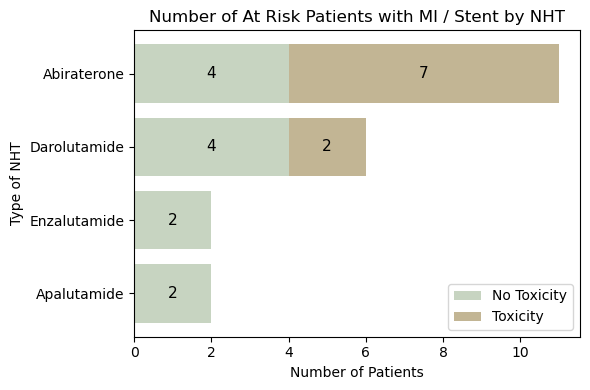

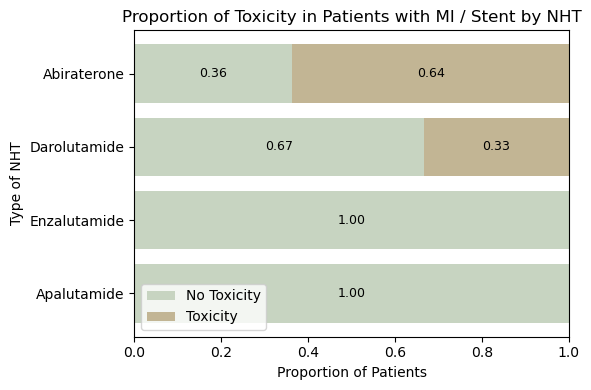

specific_nht_used
Abiraterone     0.636364
Apalutamide     0.000000
Darolutamide    0.333333
Enzalutamide    0.000000
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.3030
Chi-square p-value: 0.4916
Fisher's Exact p-value: 0.3348
Chi-square p-value (full): 0.1603
Fisher's Exact p-value (full): 0.1618
  Apalutamide vs Abiraterone: p = 0.192
  Apalutamide vs Darolutamide: p = 1.000
  Apalutamide vs Enzalutamide: p = 1.000
  Abiraterone vs Darolutamide: p = 0.335
  Abiraterone vs Enzalutamide: p = 0.192
  Darolutamide vs Enzalutamide: p = 1.000

History of CHF


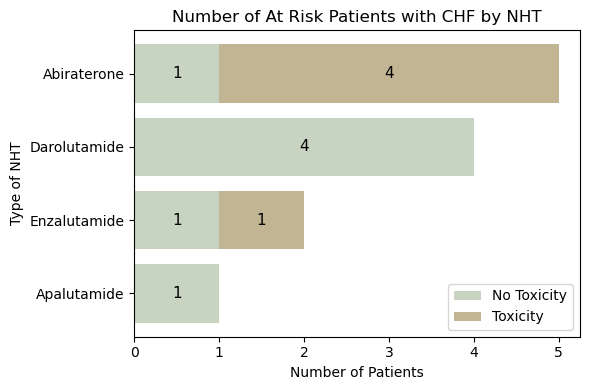

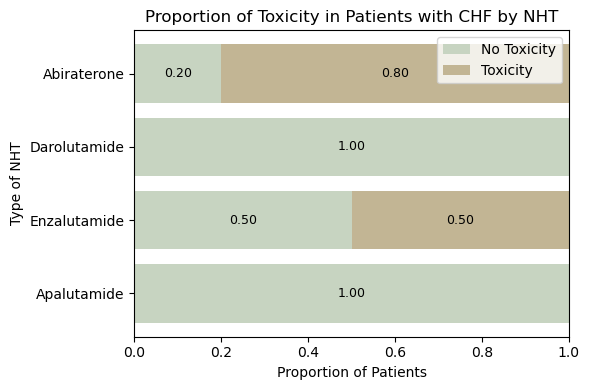

specific_nht_used
Abiraterone     0.8
Apalutamide     0.0
Darolutamide    0.0
Enzalutamide    0.5
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.8000
Chi-square p-value: 0.0845
Fisher's Exact p-value: 0.0476
Chi-square p-value (full): 0.0839
Fisher's Exact p-value (full): 0.0783
  Abiraterone vs Darolutamide: p = 0.048
  Abiraterone vs Enzalutamide: p = 1.000
  Abiraterone vs Apalutamide: p = 0.333
  Darolutamide vs Enzalutamide: p = 0.333
  Darolutamide vs Apalutamide: p = 1.000
  Enzalutamide vs Apalutamide: p = 1.000

History of Arrhythmia


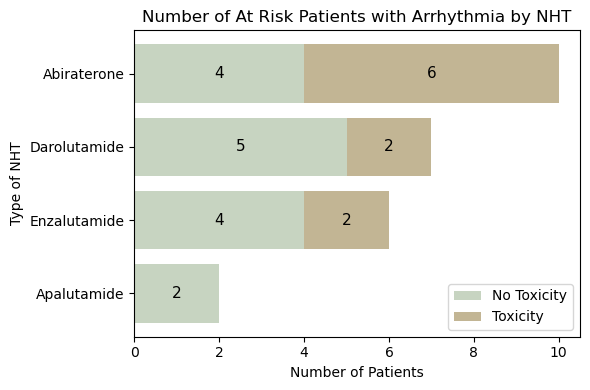

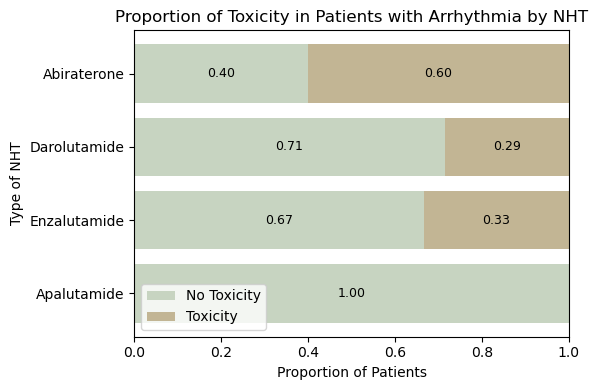

specific_nht_used
Abiraterone     0.600000
Apalutamide     0.000000
Darolutamide    0.285714
Enzalutamide    0.333333
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.3143
Chi-square p-value: 0.4330
Fisher's Exact p-value: 0.3348
Chi-square p-value (full): 0.3218
Fisher's Exact p-value (full): 0.4622
  Abiraterone vs Darolutamide: p = 0.335
  Abiraterone vs Enzalutamide: p = 0.608
  Abiraterone vs Apalutamide: p = 0.455
  Darolutamide vs Enzalutamide: p = 1.000
  Darolutamide vs Apalutamide: p = 1.000
  Enzalutamide vs Apalutamide: p = 1.000

History of CAD


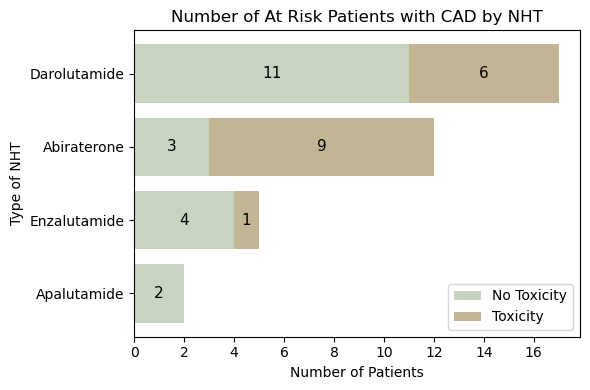

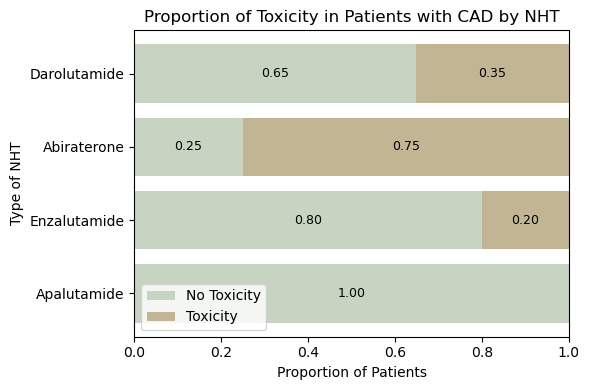

specific_nht_used
Abiraterone     0.750000
Apalutamide     0.000000
Darolutamide    0.352941
Enzalutamide    0.200000
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.3971
Chi-square p-value: 0.0836
Fisher's Exact p-value: 0.0604
Chi-square p-value (full): 0.0476
Fisher's Exact p-value (full): 0.0484
  Abiraterone vs Darolutamide: p = 0.060
  Abiraterone vs Enzalutamide: p = 0.101
  Abiraterone vs Apalutamide: p = 0.110
  Darolutamide vs Enzalutamide: p = 1.000
  Darolutamide vs Apalutamide: p = 1.000
  Enzalutamide vs Apalutamide: p = 1.000

History of Carotid Disease


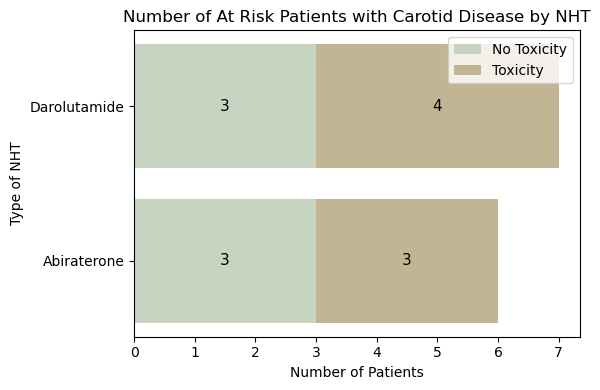

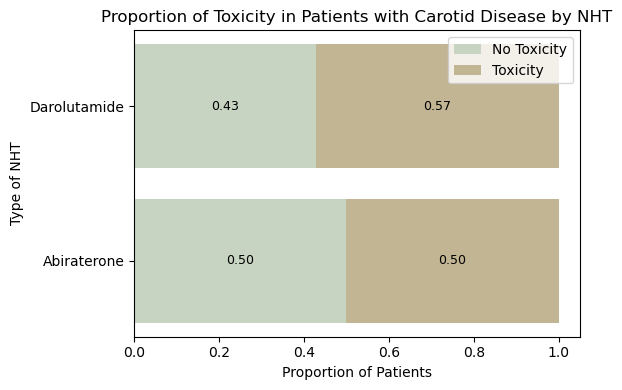

specific_nht_used
Abiraterone     0.500000
Darolutamide    0.571429
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): -0.0714
Chi-square p-value: 1.0000
Fisher's Exact p-value: 1.0000
Chi-square p-value (full): 1.0000
Fisher's Exact p-value (full): 1.0000
  Abiraterone vs Darolutamide: p = 1.000

History of PVD / PAD


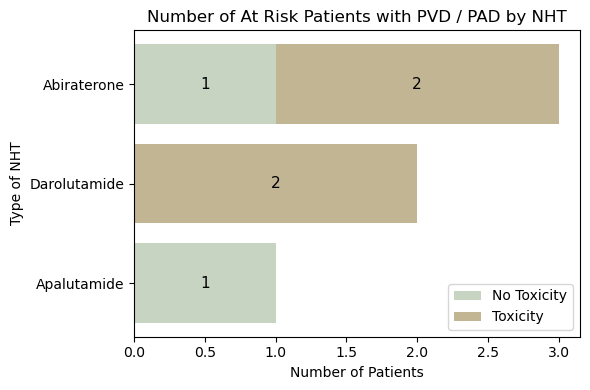

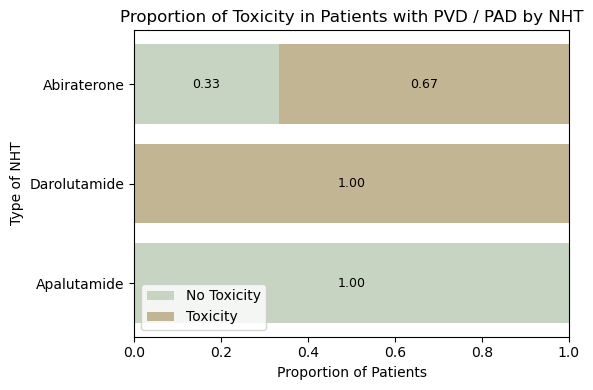

specific_nht_used
Abiraterone     0.666667
Apalutamide     0.000000
Darolutamide    1.000000
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): -0.3333
Chi-square p-value: 1.0000
Fisher's Exact p-value: 1.0000
Chi-square p-value (full): 0.2231
Fisher's Exact p-value (full): 0.5990
  Darolutamide vs Abiraterone: p = 1.000
  Darolutamide vs Apalutamide: p = 0.333
  Abiraterone vs Apalutamide: p = 1.000

History of Smoking


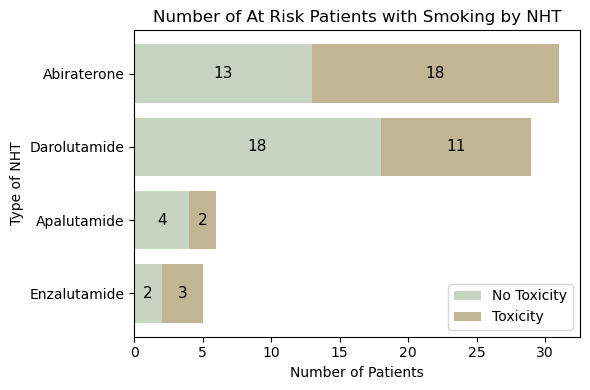

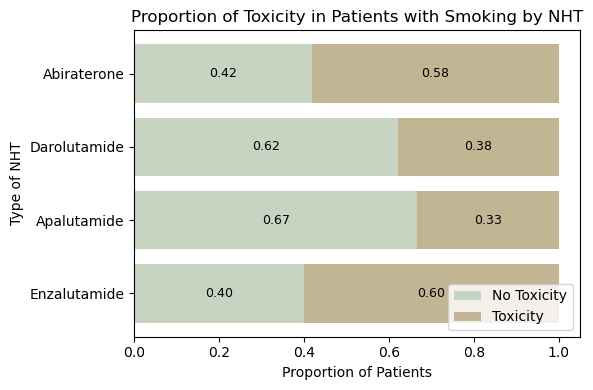

specific_nht_used
Abiraterone     0.580645
Apalutamide     0.333333
Darolutamide    0.379310
Enzalutamide    0.600000
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.2013
Chi-square p-value: 0.1932
Fisher's Exact p-value: 0.1319
Chi-square p-value (full): 0.3558
Fisher's Exact p-value (full): 0.3486
  Darolutamide vs Abiraterone: p = 0.132
  Darolutamide vs Apalutamide: p = 1.000
  Darolutamide vs Enzalutamide: p = 0.627
  Abiraterone vs Apalutamide: p = 0.383
  Abiraterone vs Enzalutamide: p = 1.000
  Apalutamide vs Enzalutamide: p = 0.567

History of Stroke


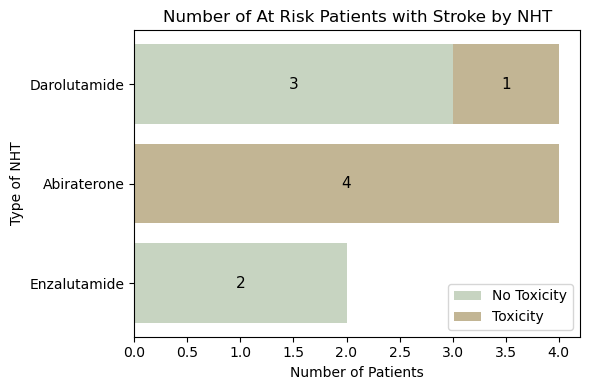

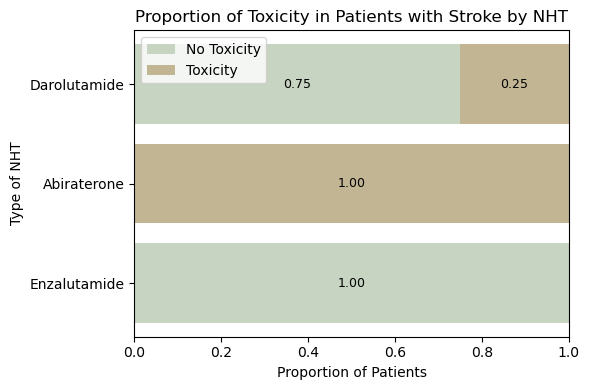

specific_nht_used
Abiraterone     1.00
Darolutamide    0.25
Enzalutamide    0.00
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.7500
Chi-square p-value: 0.1441
Fisher's Exact p-value: 0.1429
Chi-square p-value (full): 0.0302
Fisher's Exact p-value (full): 0.0825
  Abiraterone vs Enzalutamide: p = 0.067
  Abiraterone vs Darolutamide: p = 0.143
  Enzalutamide vs Darolutamide: p = 1.000

Family History of Heart Disease


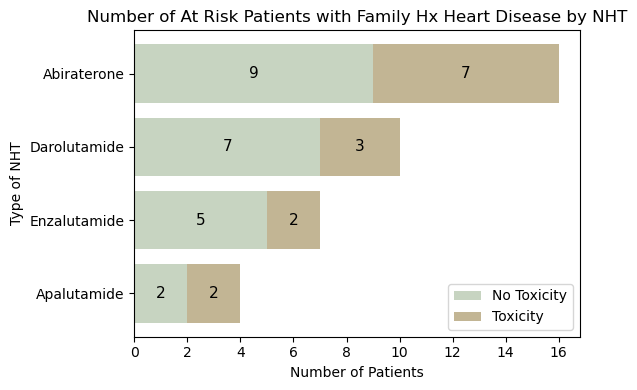

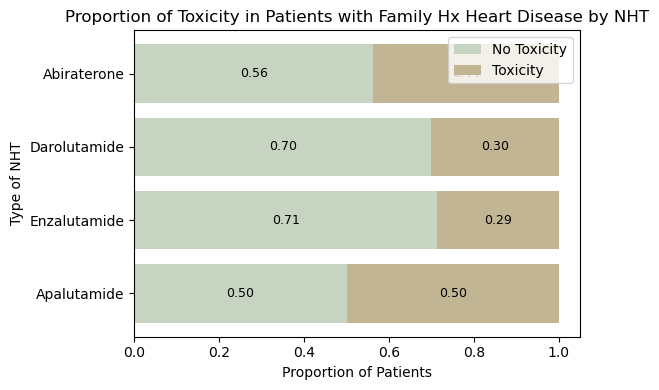

specific_nht_used
Abiraterone     0.437500
Apalutamide     0.500000
Darolutamide    0.300000
Enzalutamide    0.285714
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.1375
Chi-square p-value: 0.7743
Fisher's Exact p-value: 0.6834
Chi-square p-value (full): 0.7998
Fisher's Exact p-value (full): 0.7916
  Abiraterone vs Darolutamide: p = 0.683
  Abiraterone vs Apalutamide: p = 1.000
  Abiraterone vs Enzalutamide: p = 0.657
  Darolutamide vs Apalutamide: p = 0.580
  Darolutamide vs Enzalutamide: p = 1.000
  Apalutamide vs Enzalutamide: p = 0.576

History of High Triglycerides


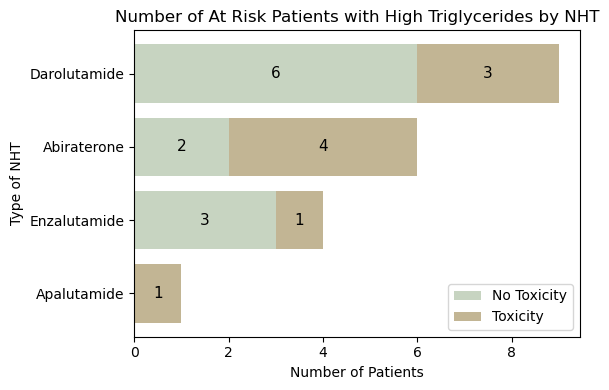

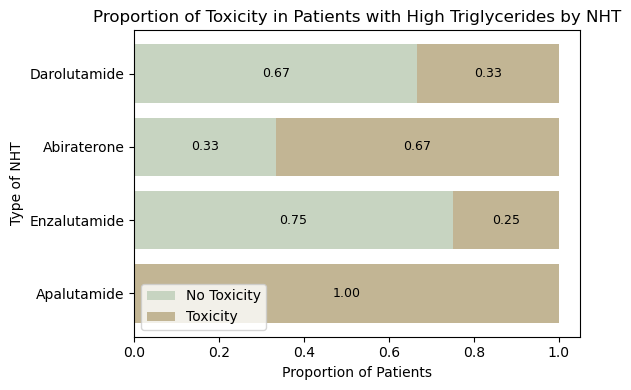

specific_nht_used
Abiraterone     0.666667
Apalutamide     1.000000
Darolutamide    0.333333
Enzalutamide    0.250000
Name: at_risk, dtype: float64
Risk diff (Abiraterone - Darolutamide): 0.3333
Chi-square p-value: 0.4596
Fisher's Exact p-value: 0.3147
Chi-square p-value (full): 0.3205
Fisher's Exact p-value (full): 0.3753
  Darolutamide vs Abiraterone: p = 0.315
  Darolutamide vs Enzalutamide: p = 1.000
  Darolutamide vs Apalutamide: p = 0.400
  Abiraterone vs Enzalutamide: p = 0.524
  Abiraterone vs Apalutamide: p = 1.000
  Enzalutamide vs Apalutamide: p = 0.400


In [20]:
hx_conditions = [
    ("hx_htn",        "History of Hypertension",       "Hypertension"),
    ("hx_hld",        "History of Hyperlipidemia",      "Hyperlipidemia"),
    ("hx_dm2",        "History of Diabetes",            "Diabetes"),
    ("hx_mi_stent",   "History of MI / Stent",          "MI / Stent"),
    ("hx_chf",        "History of CHF",                 "CHF"),
    ("hx_arrhythmia", "History of Arrhythmia",          "Arrhythmia"),
    ("hx_cad",        "History of CAD",                 "CAD"),
    ("hx_carotid",    "History of Carotid Disease",     "Carotid Disease"),
    ("hx_pad",        "History of PVD / PAD",           "PVD / PAD"),
    ("hx_smoking",    "History of Smoking",             "Smoking"),
    ("hx_cva",        "History of Stroke",              "Stroke"),
    ("family_hx_hd",  "Family History of Heart Disease","Family Hx Heart Disease"),
    ("hx_high_tg",    "History of High Triglycerides",  "High Triglycerides"),
]

for col, section_label, plot_label in hx_conditions:
    print(f"\n{'='*60}")
    print(section_label)
    print('='*60)
    hx_nht_analysis(df, col, plot_label)

    # All-drug pairwise Fisher (where applicable)
    subset = df[CONDITION_FILTER[col](df[col])]
    drugs  = subset["specific_nht_used"].unique()
    for a, b in combinations(drugs, 2):
        sub = subset[subset["specific_nht_used"].isin([a, b])]
        tbl = pd.crosstab(sub["specific_nht_used"], sub["at_risk"])
        _, p = fisher_exact(tbl)
        print(f"  {a} vs {b}: p = {p:.3f}")

### Cardiology Intervention

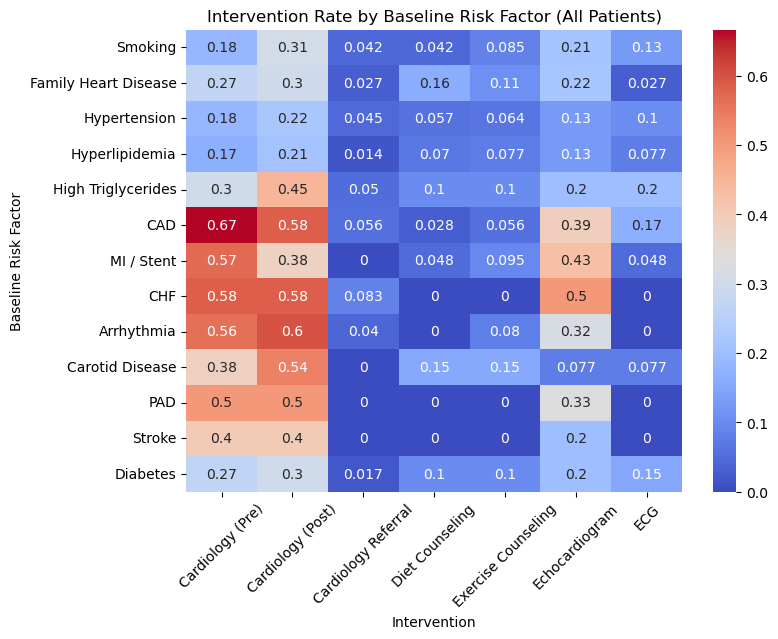

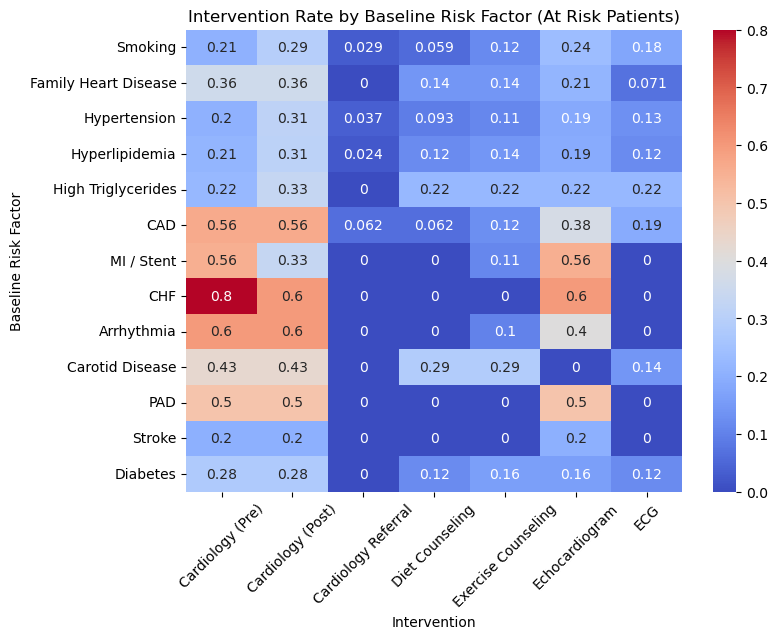

In [21]:
interventions = list(INTERVENTION_NAMES.keys())

# Heatmap — all patients
heat = pd.DataFrame(index=RISK_FACTORS, columns=interventions)
for r in RISK_FACTORS:
    for i in interventions:
        heat.loc[r, i] = df[df[r] == 1][i].mean()
heat = heat.astype(float)
heat.index   = heat.index.map(CONDITION_NAMES)
heat.columns = heat.columns.map(INTERVENTION_NAMES)

for title_sfx, source in [("All Patients", heat),
                            ("At Risk Patients", heat.copy())]:
    if "At Risk" in title_sfx:
        heat2 = pd.DataFrame(index=RISK_FACTORS, columns=interventions)
        for r in RISK_FACTORS:
            for i in interventions:
                heat2.loc[r, i] = tox[tox[r] == 1][i].mean()
        heat2 = heat2.astype(float)
        heat2.index   = heat2.index.map(CONDITION_NAMES)
        heat2.columns = heat2.columns.map(INTERVENTION_NAMES)
        source = heat2
    plt.figure(figsize=(8, 6))
    sns.heatmap(source, annot=True, cmap="coolwarm")
    plt.xticks(rotation=45)
    plt.title(f"Intervention Rate by Baseline Risk Factor ({title_sfx})")
    plt.xlabel("Intervention"); plt.ylabel("Baseline Risk Factor")
    plt.show()

Cardiologist Visits of At Risk Patients

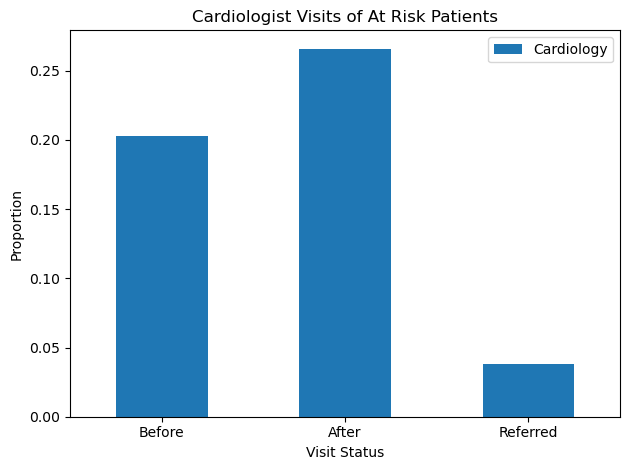

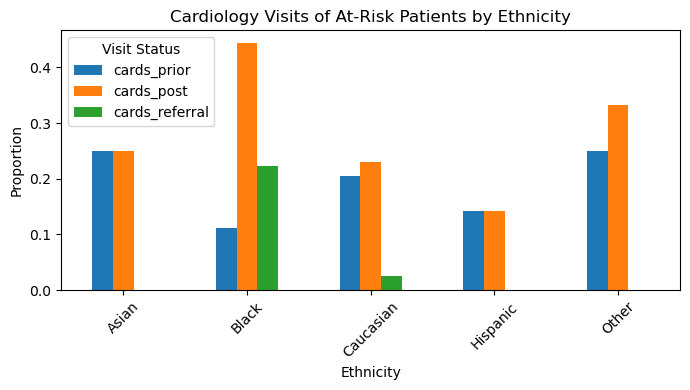

C:\Users\tiffa\AppData\Local\Temp\ipykernel_9052\3450050039.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tox.groupby(strat_col)[cardio_cols].mean().plot(kind="bar", figsize=(7, 4))


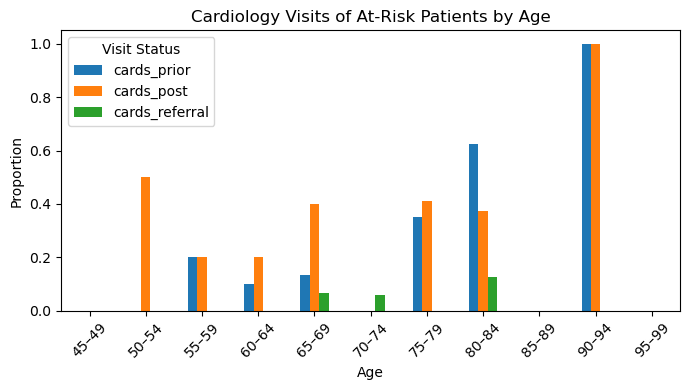

In [22]:
cardio_cols = ["cards_prior", "cards_post", "cards_referral"]
cardio_labels = {"cards_prior": "Before", "cards_post": "After", "cards_referral": "Referred"}

care = pd.DataFrame({cardio_labels[c]: tox[c].mean() for c in cardio_cols}, index=["Cardiology"])
care.T.plot(kind="bar")
plt.title("Cardiologist Visits of At Risk Patients")
plt.xticks(rotation=0); plt.xlabel("Visit Status"); plt.ylabel("Proportion")
plt.tight_layout()

for strat_col, strat_label in [("ethnicity", "Ethnicity"), ("age_bin", "Age")]:
    tox.groupby(strat_col)[cardio_cols].mean().plot(kind="bar", figsize=(7, 4))
    plt.title(f"Cardiology Visits of At-Risk Patients by {strat_label}")
    plt.xlabel(strat_label); plt.ylabel("Proportion")
    plt.xticks(rotation=45); plt.legend(title="Visit Status")
    plt.tight_layout(); plt.show()

Preventative Care of At Risk Patients

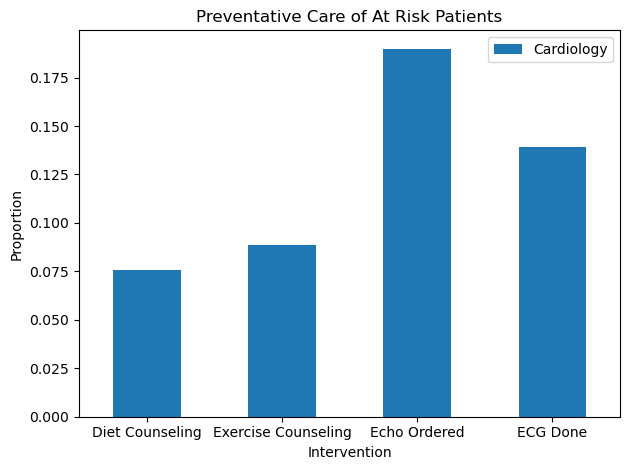

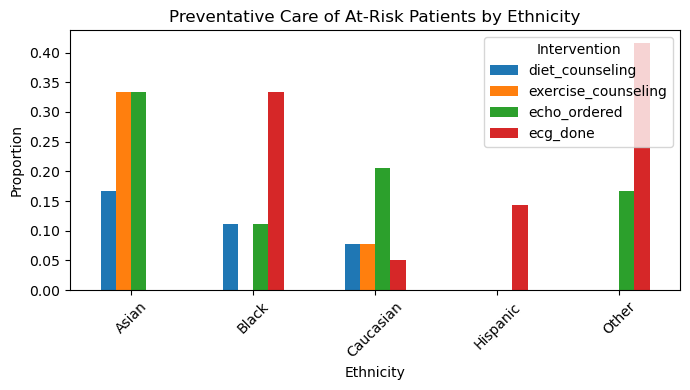

C:\Users\tiffa\AppData\Local\Temp\ipykernel_9052\1849885544.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tox.groupby(strat_col)[prev_cols].mean().plot(kind="bar", figsize=(7, 4))


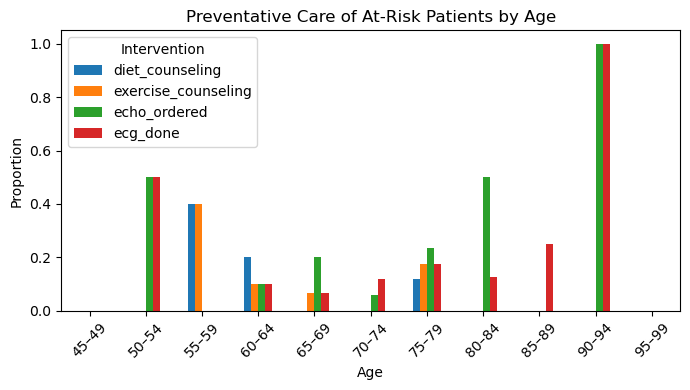

In [23]:
prev_cols   = ["diet_counseling", "exercise_counseling", "echo_ordered", "ecg_done"]
prev_labels = {"diet_counseling": "Diet Counseling", "exercise_counseling": "Exercise Counseling",
               "echo_ordered": "Echo Ordered", "ecg_done": "ECG Done"}

care = pd.DataFrame({prev_labels[c]: tox[c].mean() for c in prev_cols}, index=["Cardiology"])
care.T.plot(kind="bar")
plt.title("Preventative Care of At Risk Patients")
plt.xticks(rotation=0); plt.xlabel("Intervention"); plt.ylabel("Proportion")
plt.tight_layout()

for strat_col, strat_label in [("ethnicity", "Ethnicity"), ("age_bin", "Age")]:
    tox.groupby(strat_col)[prev_cols].mean().plot(kind="bar", figsize=(7, 4))
    plt.title(f"Preventative Care of At-Risk Patients by {strat_label}")
    plt.xlabel(strat_label); plt.ylabel("Proportion")
    plt.xticks(rotation=45); plt.legend(title="Intervention")
    plt.tight_layout(); plt.show()

### Medication History

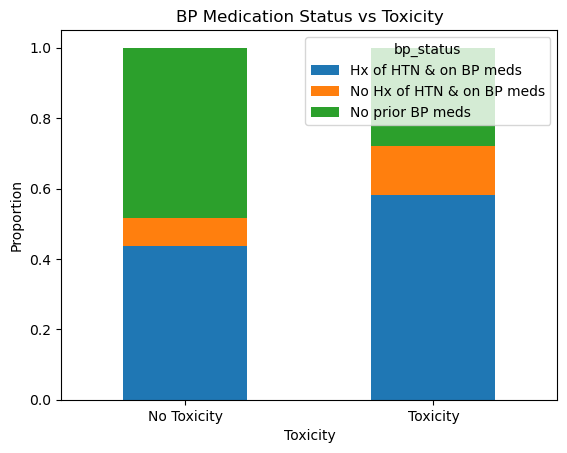

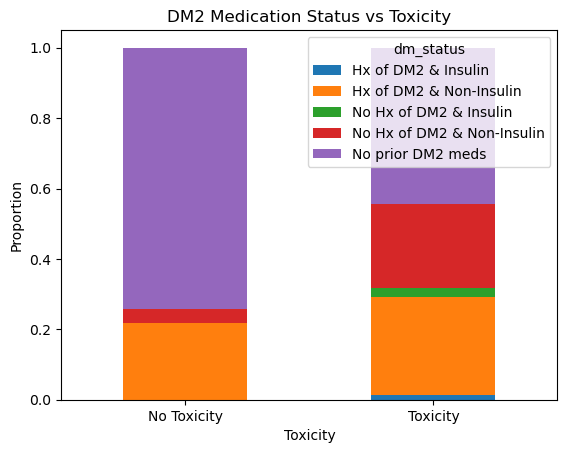

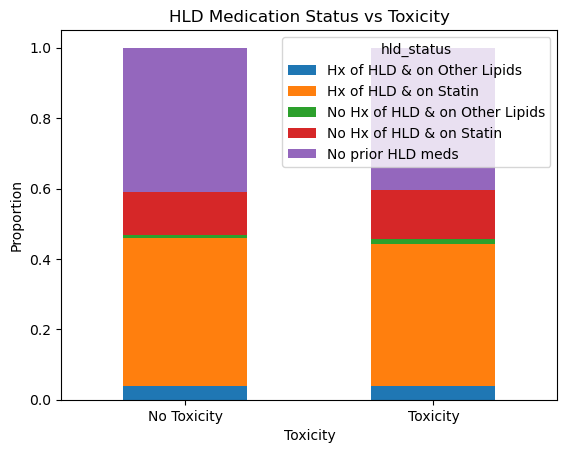

In [24]:
# BP treatment pre-NHT
df["bp_status"] = np.select(
    [(df["hx_htn"] == 1) & (df["bp_meds_prior"] == 1),
     (df["hx_htn"] == 0) & (df["bp_meds_prior"] == 1),
     (df["bp_meds_prior"] == 0)],
    ["Hx of HTN & on BP meds", "No Hx of HTN & on BP meds", "No prior BP meds"],
    default="Other",
)
# DM2 treatment pre-NHT
df["dm_status"] = np.select(
    [(df["hx_dm2"] == 1) & (df["dm_noninsulin"] == 1),
     (df["hx_dm2"] == 1) & (df["on_insulin"] == 1),
     (df["hx_dm2"] == 0) & (df["dm_noninsulin"] == 1),
     (df["hx_dm2"] == 0) & (df["on_insulin"] == 1),
     (df["dm_noninsulin"] == 0) & (df["on_insulin"] == 0)],
    ["Hx of DM2 & Non-Insulin", "Hx of DM2 & Insulin",
     "No Hx of DM2 & Non-Insulin", "No Hx of DM2 & Insulin", "No prior DM2 meds"],
    default="Other",
)
# HLD treatment pre-NHT
df["hld_status"] = np.select(
    [(df["hx_hld"] == 1) & (df["statin_prior"] == 1),
     (df["hx_hld"] == 1) & (df["other_lipid_prior"] == 1),
     (df["hx_hld"] == 0) & (df["statin_prior"] == 1),
     (df["hx_hld"] == 0) & (df["other_lipid_prior"] == 1),
     (df["statin_prior"] == 0) & (df["other_lipid_prior"] == 0)],
    ["Hx of HLD & on Statin", "Hx of HLD & on Other Lipids",
     "No Hx of HLD & on Statin", "No Hx of HLD & on Other Lipids", "No prior HLD meds"],
    default="Other",
)

for status_col, title in [
    ("bp_status",  "BP Medication Status vs Toxicity"),
    ("dm_status",  "DM2 Medication Status vs Toxicity"),
    ("hld_status", "HLD Medication Status vs Toxicity"),
]:
    plot_data = pd.crosstab(df[status_col], df["at_risk"], normalize="columns")
    ax = plot_data.T.plot(kind="bar", stacked=True)
    plt.title(title); plt.xlabel("Toxicity"); plt.ylabel("Proportion")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No Toxicity", "Toxicity"], rotation=0)
    plt.show()

Counts of Post-NHT Treatment Types by ADT and NHT

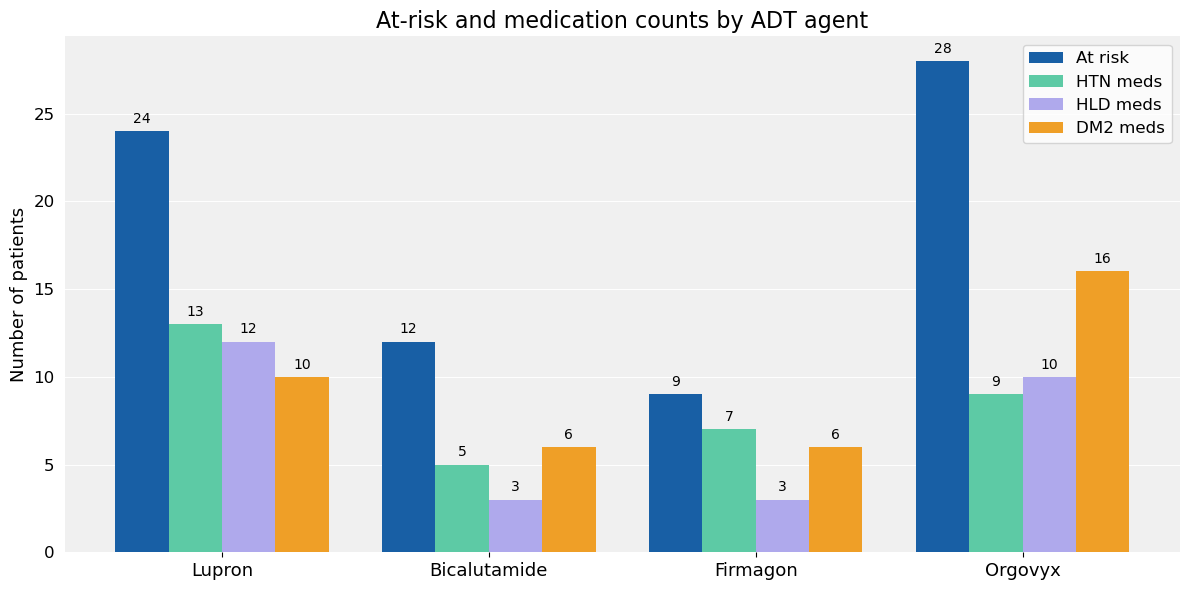

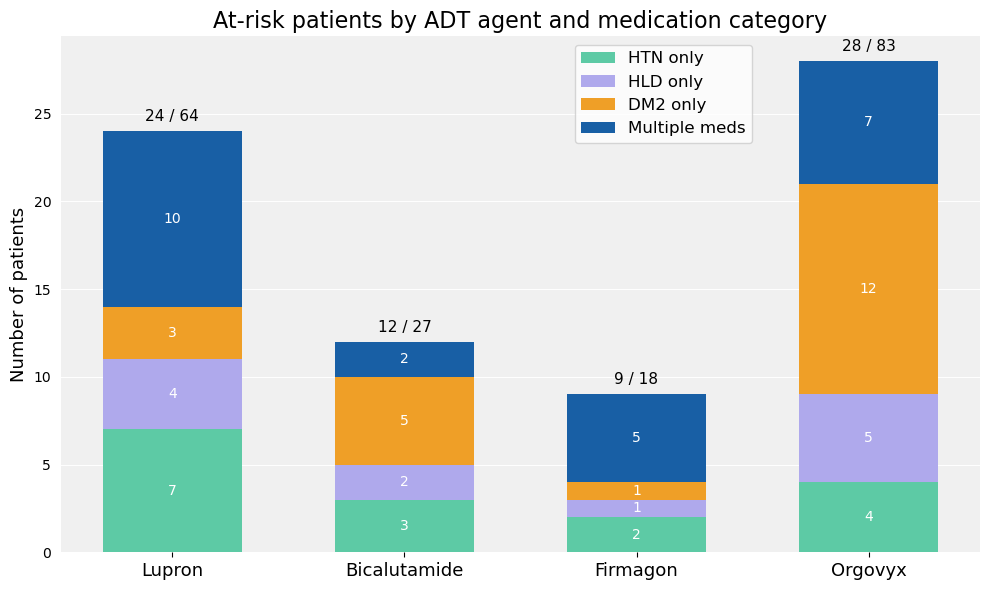

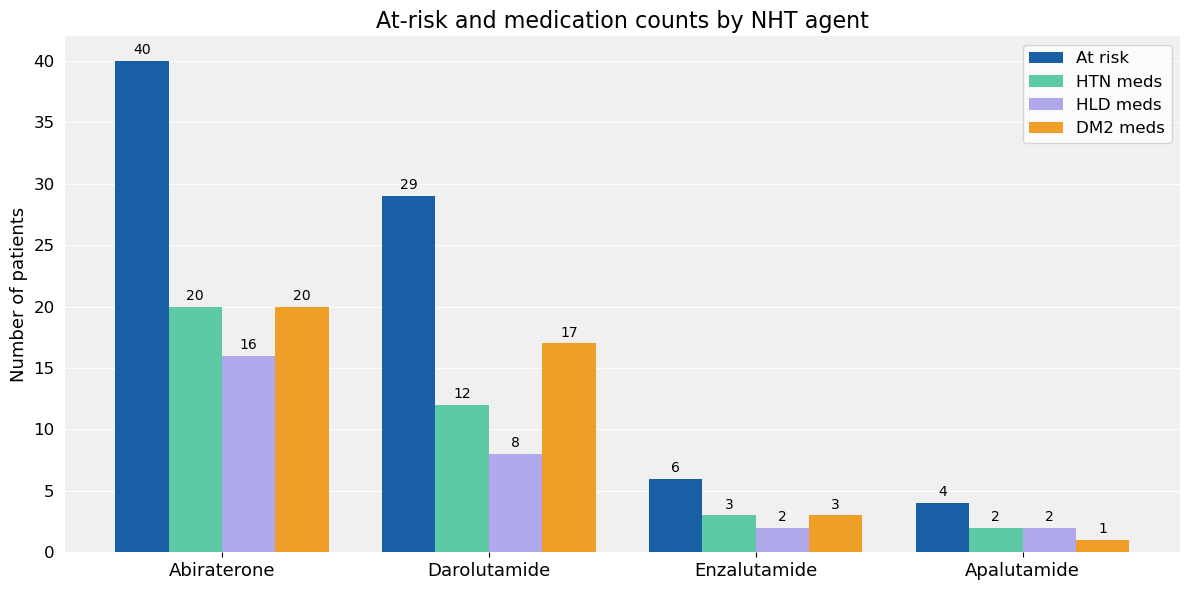

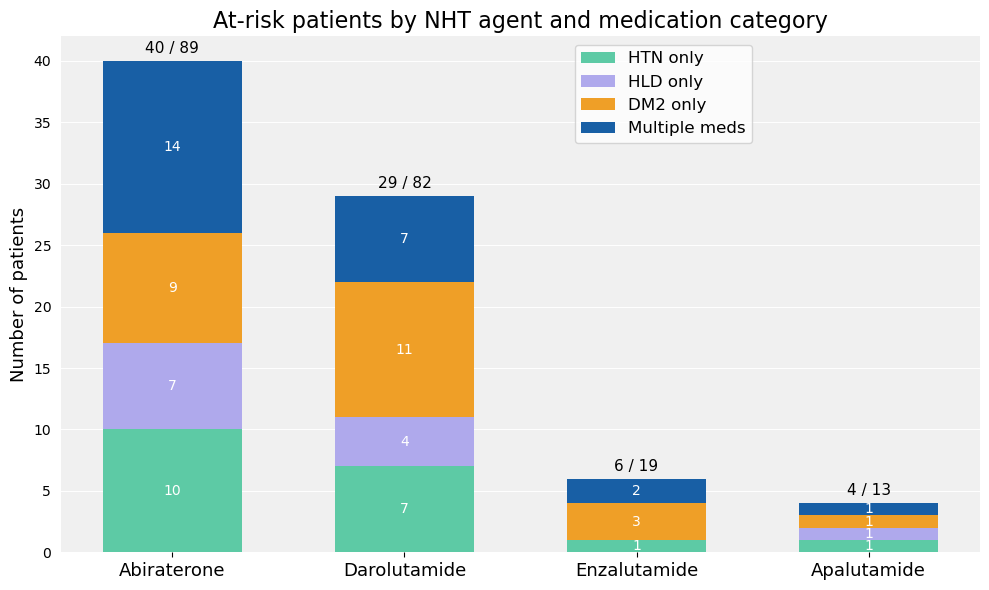

In [25]:
at_risk_df = all_df[all_df["at_risk"] == 1]
med_cols   = ["bp_meds_post_binary", "lipid_meds_post_binary", "dm_meds_post_binary"]
meds       = ["at_risk"] + med_cols
med_labels = ["At risk", "HTN meds", "HLD meds", "DM2 meds"]
med_colors = ["#185fa5", "#5dcaa5", "#afa9ec", "#ef9f27"]

cat_labels  = ["HTN only", "HLD only", "DM2 only", "Multiple meds"]
cat_colors  = ["#5dcaa5", "#afa9ec", "#ef9f27", "#185fa5"]


def plot_grouped_bars(ax, agent_list, meds, med_labels, med_colors, source_df, group_col):
    """Grouped bar chart: counts per agent per metric."""
    n_metrics = len(meds)
    x = np.arange(len(agent_list))
    width = 0.8 / n_metrics
    for j, (med, label, color) in enumerate(zip(meds, med_labels, med_colors)):
        values = [
            len(source_df[source_df[group_col] == a]) if med == "at_risk"
            else source_df[source_df[group_col] == a][med].sum()
            for a in agent_list
        ]
        bars = ax.bar(x + j * width, values, width=width, label=label, color=color)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                    f"{int(h)}", ha="center", va="bottom", fontsize=10)
    ax.set_xticks(x + width * (n_metrics - 1) / 2)
    ax.set_xticklabels(agent_list, fontsize=13)
    return x


def plot_stacked_meds(ax, agent_list, ar, group_col, all_source):
    """Stacked bar chart: mutually exclusive medication categories."""
    ar = ar.copy()
    ar["med_count"]   = ar[med_cols].sum(axis=1)
    ar["cat_htn_only"] = ((ar["bp_meds_post_binary"]    == 1) & (ar["med_count"] == 1)).astype(int)
    ar["cat_hld_only"] = ((ar["lipid_meds_post_binary"] == 1) & (ar["med_count"] == 1)).astype(int)
    ar["cat_dm2_only"] = ((ar["dm_meds_post_binary"]    == 1) & (ar["med_count"] == 1)).astype(int)
    ar["cat_multi"]    = (ar["med_count"] > 1).astype(int)
    cats = ["cat_htn_only", "cat_hld_only", "cat_dm2_only", "cat_multi"]

    agent_counts = {a: [ar[ar[group_col] == a][c].sum() for c in cats] for a in agent_list}
    x = np.arange(len(agent_list))
    bottoms = np.zeros(len(agent_list))
    for j, (cat, label, color) in enumerate(zip(cats, cat_labels, cat_colors)):
        values = np.array([agent_counts[a][j] for a in agent_list])
        bars = ax.bar(x, values, bottom=bottoms, label=label, color=color, width=0.6)
        for k, bar in enumerate(bars):
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bottoms[k] + h / 2,
                        f"{int(h)}", ha="center", va="center",
                        fontsize=10, color="white")
        bottoms += values
    for k, xi in enumerate(x):
        total_all = len(all_source[all_source[group_col] == agent_list[xi]])
        ax.text(xi, bottoms[k] + 0.4, f"{int(bottoms[k])} / {total_all}",
                ha="center", va="bottom", fontsize=11, color="black")
    ax.set_xticks(x); ax.set_xticklabels(agent_list, fontsize=13)
    


for group_col, title_label in [("adt_agent", "ADT"), ("specific_nht_used", "NHT")]:
    agent_list = at_risk_df[group_col].dropna().unique()

    # Grouped bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_grouped_bars(ax, agent_list, meds, med_labels, med_colors, at_risk_df, group_col)
    ax.set_ylabel("Number of patients", fontsize=13)
    ax.set_title(f"At-risk and medication counts by {title_label} agent", fontsize=16)
    ax.tick_params(axis="y", labelsize=12); ax.legend(fontsize=12)
    styled_bar_chart(ax)
    plt.tight_layout(); plt.show()

    # Stacked medication-category chart
    ar_copy = at_risk_df.copy()
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_stacked_meds(ax, agent_list, ar_copy, group_col, all_df)
    ax.set_ylabel("Number of patients", fontsize=13)
    ax.set_title(f"At-risk patients by {title_label} agent and medication category", fontsize=16)
    ax.legend(fontsize=12, bbox_to_anchor=(0.55, 1), loc="upper left")
    styled_bar_chart(ax)
    plt.tight_layout(); plt.show()

At-Risk Patients on New BP Medications Post-NHT by ADT

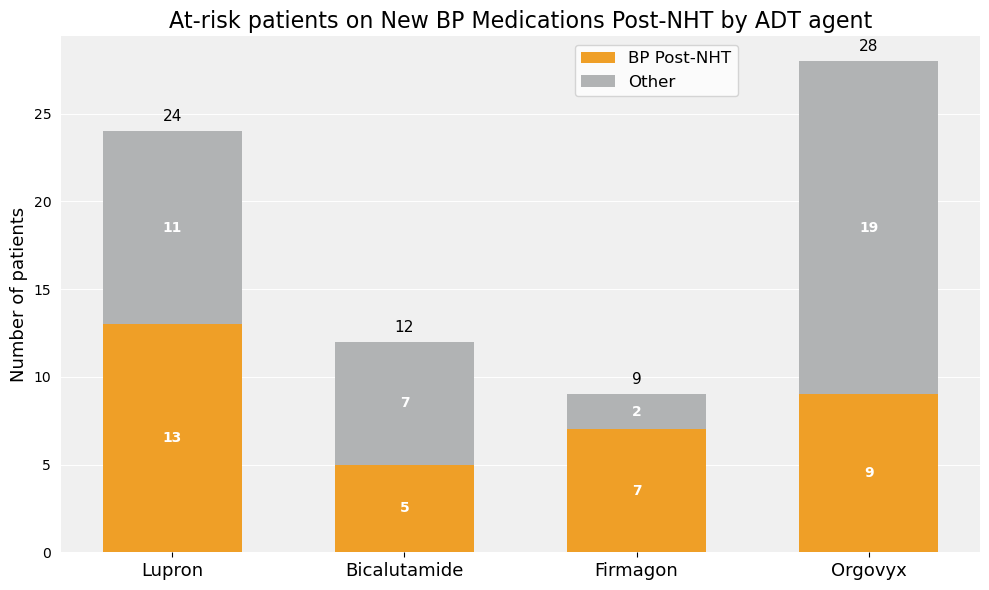

In [26]:
ar = at_risk_df.copy()
ar["cat_htn_only"] = ar["bp_meds_post_binary"] == 1
ar["risk"]         = ar["at_risk"] == 1

agent_list = ar["adt_agent"].dropna().unique()
counts_bp = {
    a: [ar[ar["adt_agent"] == a]["cat_htn_only"].sum(),
        ar[ar["adt_agent"] == a]["risk"].sum() - ar[ar["adt_agent"] == a]["cat_htn_only"].sum()]
    for a in agent_list
}

x = np.arange(len(agent_list))
fig, ax = plt.subplots(figsize=(10, 6))
bottoms = np.zeros(len(agent_list))
for j, (label, color) in enumerate([("BP Post-NHT", "#ef9f27"), ("Other", "#b1b3b4")]):
    values = np.array([counts_bp[a][j] for a in agent_list])
    bars = ax.bar(x, values, bottom=bottoms, label=label, color=color, width=0.6)
    for k, bar in enumerate(bars):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bottoms[k] + h / 2,
                    f"{int(h)}", ha="center", va="center",
                    fontsize=10, color="white", fontweight="bold")
    bottoms += values
for k, xi in enumerate(x):
    ax.text(xi, bottoms[k] + 0.4, f"{int(bottoms[k])}",
            ha="center", va="bottom", fontsize=11, color="black")

ax.set_xticks(x); ax.set_xticklabels(agent_list, fontsize=13)
ax.set_ylabel("Number of patients", fontsize=13)
ax.set_title("At-risk patients on New BP Medications Post-NHT by ADT agent", fontsize=16)
ax.legend(fontsize=12, bbox_to_anchor=(0.55, 1), loc="upper left")
styled_bar_chart(ax)
plt.tight_layout(); plt.show()